# ADL Challenge - Spacepresso

**Before starting:** upload the competition data to your preferred folder and make sure Google Drive is mounted.

## Solution Overview

### Method: Supervised Patch MLP Ensemble

We adopt a **semi-supervised patch-based approach**: a lightweight MLP binary classifier
trained on backbone patch features extracted from both normal and anomalous training
images, using the provided pixel-level masks as supervision.

For each image, the backbone produces a spatial feature grid (e.g. 28×28 patches).
Each patch is classified as normal (0) or anomalous (1) by the MLP. The resulting
score map is upsampled to image resolution and Gaussian-smoothed to produce the
final anomaly map.

### Backbone Ensemble

We train three independent MLPs on three different backbone feature spaces and
combine them via **per-pixel max**:

| Backbone | Type | Grid | Feat dim | Key strength |
|---|---|---|---|---|
| WideResNet50-2 | CNN (ImageNet) | 28×28 | 1536 | Precise local texture |
| DINOv2 ViT-B/14 | ViT (self-supervised) | 16×16 | 3072 | Semantic generalization to unseen defect types |
| ConvNeXT-Large | CNN (ImageNet) | 28×28 | 1152 | Different CNN inductive bias from WR50 |

Per-pixel max rather than averaging preserves each model's full confidence —
a defect detected by any one model contributes its full score without being
diluted by the other two models' low scores on that region.

---

### Training Details

**Loss**: Focal loss (γ=2, α auto-computed from class ratio) — handles the extreme
class imbalance (~1% anomalous patches).

**Augmentation**: WR50 and ConvNeXT use rotational augmentation on anomaly images
(0°/90°/180°/270° + flips for symmetric classes) to multiply the limited anomaly
training set. DINOv2 uses no augmentation but enables **Hard Negative Mining** (HNM):
a second training pass that focuses on the normal patches the model scores highest,
sharpening the decision boundary.

**Class-wise training**: one MLP per product class, since defect appearances
differ significantly across classes.

---

### Post-Processing

1. **Background suppression**: zero out predictions in the black outer border.
2. **Test-Time Augmentation (TTA)**: average predictions over D4/Klein-4
   rotations and flips, which reduces directional bias in CNN features.
3. **Multi-view fusion**: propagate the max score across all 5 views of the same
   sample, if any view shows a strong anomaly, all views are boosted to match.
4. **Multi-view consistency**: further boost samples where views strongly disagree,
   since real defects tend to appear consistently across multiple viewpoints.

---

### Final Results

| Configuration | Kaggle Pixel AP (Public Leaderboard) |
|---|---|
| WR50 alone | 0.8245 |
| WR50 + DINOv2 ViT-S | 0.8559 |
| WR50 + DINOv2 ViT-B | 0.8674 |
| **WR50 + DINOv2 ViT-B + ConvNeXT-L** | **0.8781** |

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess, sys
# timm provides pretrained WideResNet50 and ConvNeXT feature extractors.
# DINOv2 is loaded separately via torch.hub (built into PyTorch).
pkgs = ['timm']  # add any missing package here
for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

# Where to save predictions on Google Drive
GDRIVE_SUBMISSIONS = '/content/drive/MyDrive/ADL/Project/predictions'

print(f'Drive output: {GDRIVE_SUBMISSIONS}')

ModuleNotFoundError: No module named 'google'

In [ ]:
ZIPPED = False # set to True if you hold the data in zipped format

import shutil, os
# uncomment if you need to clean local data
#shutil.rmtree('/content/data/spacepresso')  # wipe the partial copy

from tqdm.notebook import tqdm

LOCAL_DATA = '/content/data/'
shutil.rmtree(LOCAL_DATA, ignore_errors=True)

# ── Option A: unzipped folder on Drive ──────────────────────────────────────
SRC = '/content/drive/MyDrive/ADL/Project/data/spacepresso'
if os.path.exists(SRC) and not ZIPPED:
    total = sum(len(files) for _, _, files in os.walk(SRC))
    print(f"Copying {total:,} files to local SSD...")
    with tqdm(total=total, unit='file') as pbar:
        def _copy(src, dst):
            shutil.copy2(src, dst)
            pbar.update(1)
        shutil.copytree(SRC, LOCAL_DATA, copy_function=_copy)
    print("Done.")

# ── Option B: zip file on Drive (much faster) ────────────────────────────────
else:
    ZIP_SRC = '/content/drive/MyDrive/ADL/Project/data/spacepresso.zip'
    print("Copying zip from Drive...")
    shutil.copy2(ZIP_SRC, '/content/spacepresso.zip')
    print("Extracting...")
    os.makedirs('/content/data/spacepresso', exist_ok=True)
    os.system('unzip -q /content/spacepresso.zip -d /content/data/')
    os.remove('/content/spacepresso.zip')  # free up space
    print("Done.")

DATA_ROOT = LOCAL_DATA
print(f"Data root: {DATA_ROOT}")
print(f"Classes found: {sorted(os.listdir(LOCAL_DATA))}")

Copying data from Drive to local SSD...
Done.


In [ ]:
# ── Local run setup ────────────────────────────────
# Run this instead of the Drive mount + data copy cells above.
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent  # handle running from notebooks/ subfolder

DATA_ROOT         = str(ROOT / 'data' / 'spacepresso')
GDRIVE_SUBMISSIONS = str(ROOT / 'submissions')

Path(GDRIVE_SUBMISSIONS).mkdir(parents=True, exist_ok=True)

print(f'Data root        : {DATA_ROOT}')
print(f'Output directory : {GDRIVE_SUBMISSIONS}')

Data root        : C:\Users\PC\Desktop\GITHUB REPO\Spacespresso\data\spacepresso
Output directory : C:\Users\PC\Desktop\GITHUB REPO\Spacespresso\submissions


## Initialization


In [ ]:
from __future__ import annotations

from pathlib import Path
import sys, os, random, zipfile, re, importlib
from datetime import datetime
from collections import defaultdict
from dataclasses import dataclass
from abc import ABC, abstractmethod
from typing import Any, Iterable

import numpy as np
import pandas as pd
from PIL import Image as PILImage

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

try:
    import timm
except ImportError:
    print("timm not found — install with: pip install timm")

try:
    from scipy.ndimage import gaussian_filter, binary_fill_holes
    from scipy.ndimage import binary_dilation as _bdilate
except ImportError:
    print("scipy not found — install with: pip install scipy")

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(it, **kw): return it

import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
print("PyTorch:", torch.__version__)

c:\Users\PC\anaconda3\envs\adl_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
Device: NVIDIA GeForce RTX 4060 Ti
PyTorch: 2.3.1


In [ ]:
# q8rle utilities

_HEADER = "q8rle"


def _as_unit_float_matrix(x: np.ndarray) -> np.ndarray:
    arr = np.asarray(x, dtype=np.float32)
    if arr.ndim != 2:
        raise ValueError(f"q8rle expects a 2D matrix, got shape {arr.shape}")
    arr = np.nan_to_num(arr, nan=0.0, posinf=1.0, neginf=0.0)
    return np.clip(arr, 0.0, 1.0)


def float_matrix_to_q8rle(x: np.ndarray) -> str:
    """Encode a 2D float map in [0, 1] as quantized 8-bit RLE."""
    arr = _as_unit_float_matrix(x)
    h, w = arr.shape
    q = np.rint(arr * 255.0).astype(np.uint8)
    flat = q.T.reshape(-1)

    if flat.size == 0:
        return f"{_HEADER} {h} {w}"

    runs: list[str] = []
    prev = int(flat[0])
    count = 1
    for value in flat[1:]:
        value_int = int(value)
        if value_int == prev:
            count += 1
        else:
            runs.extend([str(prev), str(count)])
            prev = value_int
            count = 1
    runs.extend([str(prev), str(count)])

    return " ".join([_HEADER, str(h), str(w), *runs])


def q8rle_to_float_matrix(s: str) -> np.ndarray:
    """Decode a q8rle string produced by float_matrix_to_q8rle."""
    if not isinstance(s, str) or not s.startswith(_HEADER):
        raise ValueError("q8rle string must start with 'q8rle'")

    tokens = [t for t in re.split(r"[\s:]+", s.strip()) if t]
    if len(tokens) < 3 or tokens[0] != _HEADER:
        raise ValueError("Invalid q8rle header")

    h = int(tokens[1])
    w = int(tokens[2])
    payload = tokens[3:]
    if len(payload) % 2 != 0:
        raise ValueError("q8rle payload must contain value/run pairs")

    values: list[np.ndarray] = []
    total = 0
    for value_token, run_token in zip(payload[0::2], payload[1::2]):
        value = int(value_token)
        run = int(run_token)
        if value < 0 or value > 255:
            raise ValueError(f"q8rle value out of uint8 range: {value}")
        if run < 0:
            raise ValueError(f"q8rle run length must be non-negative: {run}")
        if run:
            values.append(np.full(run, value, dtype=np.uint8))
            total += run

    expected = h * w
    if total != expected:
        raise ValueError(f"Decoded q8rle length {total} does not match shape {h}x{w}")

    flat = np.concatenate(values) if values else np.array([], dtype=np.uint8)
    q = flat.reshape(w, h).T
    return q.astype(np.float32) / 255.0

In [ ]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    try:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
    except Exception:
        pass


def resolve_path(path: str | Path, base: str | Path | None = None) -> Path:
    path = Path(path).expanduser()
    if path.is_absolute():
        return path
    root = Path(base).expanduser() if base is not None else Path.cwd()
    return (root / path).resolve()


def ensure_dir(path: str | Path) -> Path:
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


@dataclass(slots=True)
class ImageSample:
    image_id: str
    sample_id: str
    class_name: str
    view_id: str
    split: str
    image_path: Path
    image: np.ndarray | None = None
    label: int | None = None
    mask_path: Path | None = None
    anomaly_type: str | None = None


print("Seed / paths / sample dataclasses defined.")

Seed / paths / sample dataclasses defined.


In [ ]:
IMAGE_EXTENSIONS = {".bmp", ".jpeg", ".jpg", ".png", ".tif", ".tiff", ".webp"}


def parse_image_filename(path: str | Path) -> tuple[str, str, str]:
    # Returns (image_id, sample_id, view_id).
    # Each physical product is photographed from 5 angles, the view suffix
    # (e.g. "_view1") is stripped to group all views under the same sample_id.
    stem = Path(path).stem
    matches = list(re.finditer(r"(?i)(?:^|[_\-.])?(view\d+)(?=$|[_\-.])", stem))
    if not matches:
        return stem, stem, "view0"

    match = matches[-1]
    view_id = match.group(1).lower()
    sample_id = (stem[: match.start()] + stem[match.end() :]).strip("_-. ")
    sample_id = re.sub(r"[_\-.]+$", "", sample_id)
    if not sample_id:
        sample_id = stem
    return stem, sample_id, view_id


class SpacepressoDataModule:
    def __init__(
        self,
        data_root: str | Path | None = None,
        image_size: int | tuple[int, int] = 224,
        load_images: bool = True,
        root: str | Path | None = None,
    ):
        if data_root is None:
            data_root = root
        if data_root is None:
            raise ValueError("SpacepressoDataModule requires data_root or root")
        self.data_root = Path(data_root)
        self.image_size = self._normalize_image_size(image_size)
        self.load_images = bool(load_images)

    @staticmethod
    def _normalize_image_size(image_size) -> tuple[int, int]:
        if isinstance(image_size, int):
            return (image_size, image_size)
        if len(image_size) != 2:
            raise ValueError("image_size must be an int or a pair of ints")
        return (int(image_size[0]), int(image_size[1]))

    def list_classes(self) -> list[str]:
        if not self.data_root.exists():
            return []
        return sorted(p.name for p in self.data_root.glob("class_*") if p.is_dir())

    def load_train_good(self, class_name: str | None = None) -> list[ImageSample]:
        samples: list[ImageSample] = []
        for cls in self._iter_classes(class_name):
            image_dir = self.data_root / cls / "train" / "good"
            for path in self._iter_images(image_dir):
                samples.append(self._make_sample(
                    path=path, class_name=cls, split="train_good",
                    label=0, anomaly_type=None, mask_path=None,
                ))
        return samples

    def load_train_anomalies(self, class_name: str | None = None) -> list[ImageSample]:
        samples: list[ImageSample] = []
        for cls in self._iter_classes(class_name):
            train_dir = self.data_root / cls / "train"
            for anomaly_dir in sorted(train_dir.glob("anomaly_*")):
                if not anomaly_dir.is_dir():
                    continue
                anomaly_type = anomaly_dir.name
                mask_dir = self.data_root / cls / "ground_truth_train" / anomaly_type
                for path in self._iter_images(anomaly_dir):
                    samples.append(self._make_sample(
                        path=path, class_name=cls, split="train_anomaly",
                        label=1, anomaly_type=anomaly_type,
                        mask_path=self._find_mask_path(mask_dir, path),
                    ))
        return samples

    def load_test(self, class_name: str | None = None) -> list[ImageSample]:
        samples: list[ImageSample] = []
        for cls in self._iter_classes(class_name):
            image_dir = self.data_root / cls / "test"
            for path in self._iter_images(image_dir):
                samples.append(self._make_sample(
                    path=path, class_name=cls, split="test",
                    label=None, anomaly_type=None, mask_path=None,
                ))
        return samples

    def load_anomaly_descriptions(self):
        path = self.data_root / "anomaly_descriptions.csv"
        if not path.exists():
            return None
        return pd.read_csv(path)

    def _iter_classes(self, class_name: str | None):
        if class_name is None:
            yield from self.list_classes()
            return
        yield class_name

    @staticmethod
    def _iter_images(directory: Path) -> list[Path]:
        if not directory.exists():
            return []
        return sorted(
            p for p in directory.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        )

    def _make_sample(self, path, class_name, split, label, mask_path, anomaly_type) -> ImageSample:
        image_id, sample_id, view_id = parse_image_filename(path)
        image = self.load_image(path) if self.load_images else None
        return ImageSample(
            image_id=image_id, sample_id=sample_id, class_name=class_name,
            view_id=view_id, split=split, image_path=path, image=image,
            label=label, mask_path=mask_path, anomaly_type=anomaly_type,
        )

    def load_image(self, path: str | Path) -> np.ndarray:
        with PILImage.open(path) as image:
            image = image.convert("RGB")
            image = image.resize(self.image_size[::-1], resample=PILImage.BILINEAR)
            # PIL.resize expects (width, height); image_size is stored as (height, width)
            return np.asarray(image, dtype=np.float32) / 255.0

    @staticmethod
    def _find_mask_path(mask_dir: Path, image_path: Path) -> Path | None:
        if not mask_dir.exists():
            return None
        stem = image_path.stem
        for ext in IMAGE_EXTENSIONS:
            candidate = mask_dir / f"{stem}{ext}"
            if candidate.exists():
                return candidate
        matches = sorted(
            p for p in mask_dir.glob(f"{stem}*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        )
        return matches[0] if matches else None


print("SpacepressoDataModule defined.")

SpacepressoDataModule defined.


In [ ]:
@dataclass(slots=True)
class EvaluationResult:
    pixel_ap: float
    image_ap: float
    pixel_auroc: float | None
    image_auroc: float | None
    n_images: int
    n_anomaly_pixels: int

    def as_dict(self) -> dict:
        return {
            "pixel_ap": self.pixel_ap,
            "image_ap": self.image_ap,
            "pixel_auroc": self.pixel_auroc,
            "image_auroc": self.image_auroc,
            "n_images": self.n_images,
            "n_anomaly_pixels": self.n_anomaly_pixels,
        }


def load_sample_mask(sample: ImageSample, shape: tuple[int, int]) -> np.ndarray:
    if sample.mask_path is None:
        return np.zeros(shape, dtype=np.uint8)
    mask_path = Path(sample.mask_path)
    if not mask_path.exists():
        return np.zeros(shape, dtype=np.uint8)
    with PILImage.open(mask_path) as image:
        image = image.convert("L")
        if image.size != (shape[1], shape[0]):
              # NEAREST resampling preserves binary mask boundaries, bilinear would
            # create fractional values at edges and misclassify border pixels.
            image = image.resize((shape[1], shape[0]), resample=PILImage.NEAREST)
        mask = np.asarray(image, dtype=np.uint8)
    return (mask > 0).astype(np.uint8)


def _as_prediction_map(x: np.ndarray) -> np.ndarray:
    arr = np.asarray(x, dtype=np.float32)
    if arr.ndim != 2:
        raise ValueError(f"Prediction must be a 2D map, got shape {arr.shape}")
    return np.nan_to_num(arr, nan=0.0, posinf=1.0, neginf=0.0)


def _average_precision(y_true: np.ndarray, y_score: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.uint8)
    y_score = np.asarray(y_score, dtype=np.float64)
    n_positive = int(np.sum(y_true))
    if n_positive == 0:
        return 0.0
    order = np.argsort(-y_score, kind="mergesort")
    y_sorted = y_true[order]
    score_sorted = y_score[order]
    # Collapse tied scores into single threshold points before computing precision/recall
    distinct = np.where(np.diff(score_sorted))[0]
    threshold_idxs = np.r_[distinct, y_true.size - 1]
    tps = np.cumsum(y_sorted)[threshold_idxs]
    fps = 1 + threshold_idxs - tps
    precision = tps / np.maximum(tps + fps, 1)
    recall = tps / n_positive
    previous_recall = np.r_[0.0, recall[:-1]]
    return float(np.sum((recall - previous_recall) * precision))


def _roc_auc(y_true: np.ndarray, y_score: np.ndarray) -> float | None:
    y_true = np.asarray(y_true, dtype=np.uint8)
    y_score = np.asarray(y_score, dtype=np.float64)
    n_positive = int(np.sum(y_true))
    n_negative = int(y_true.size - n_positive)
    if n_positive == 0 or n_negative == 0:
        return None
    order = np.argsort(y_score, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(1, y_score.size + 1)
    sorted_scores = y_score[order]
    start = 0
    while start < sorted_scores.size:
        end = start + 1
        while end < sorted_scores.size and sorted_scores[end] == sorted_scores[start]:
            end += 1
        if end - start > 1:
            ranks[order[start:end]] = float(np.mean(np.arange(start + 1, end + 1)))
        start = end
    positive_rank_sum = float(np.sum(ranks[y_true == 1]))
    auc = (positive_rank_sum - n_positive * (n_positive + 1) / 2) / (n_positive * n_negative)
    return float(auc)


def evaluate_predictions(
    samples: list[ImageSample],
    predictions: dict[str, np.ndarray],
) -> EvaluationResult:
    pixel_targets, pixel_scores, image_targets, image_scores = [], [], [], []
    for sample in samples:
        if sample.image_id not in predictions:
            raise KeyError(f"Missing prediction for image_id={sample.image_id}")
        pred = _as_prediction_map(predictions[sample.image_id])
        mask = load_sample_mask(sample, pred.shape)
        target = (mask > 0).astype(np.uint8)
        pixel_targets.append(target.reshape(-1))
        pixel_scores.append(pred.reshape(-1))
        image_targets.append(int(target.max() > 0 or sample.label == 1))
        image_scores.append(float(pred.max())) # image score = worst-case pixel
    y_pixel = np.concatenate(pixel_targets)
    s_pixel = np.concatenate(pixel_scores)
    y_image = np.asarray(image_targets, dtype=np.uint8)
    s_image = np.asarray(image_scores, dtype=np.float32)
    return EvaluationResult(
        pixel_ap=_average_precision(y_pixel, s_pixel),
        image_ap=_average_precision(y_image, s_image),
        pixel_auroc=_roc_auc(y_pixel, s_pixel),
        image_auroc=_roc_auc(y_image, s_image),
        n_images=len(samples),
        n_anomaly_pixels=int(y_pixel.sum()),
    )


print("Evaluation utilities defined.")

Evaluation utilities defined.


In [ ]:
# --- Submission ---

def _prepare_prediction_map(x: np.ndarray) -> np.ndarray:
    arr = np.asarray(x, dtype=np.float32)
    if arr.ndim != 2:
        raise ValueError(f"Prediction must be a 2D numpy array, got shape {arr.shape}")
    arr = np.nan_to_num(arr, nan=0.0, posinf=1.0, neginf=0.0)
    min_value = float(arr.min()) if arr.size else 0.0
    max_value = float(arr.max()) if arr.size else 0.0
    # Only normalizes if values are outside [0, 1]. Since our MLP uses sigmoid,
    # this is effectively a no-op in practice (just a safety net).
    if min_value < 0.0 or max_value > 1.0:
        dynamic_range = max_value - min_value
        if dynamic_range > 1e-12:
            arr = (arr - min_value) / dynamic_range
        else:
            arr = np.zeros_like(arr, dtype=np.float32)
    return np.clip(arr, 0.0, 1.0).astype(np.float32)


class SubmissionWriter:
    def __init__(self, output_path: str | Path):
        self.output_path = Path(output_path)

    def write(self, predictions: dict[str, np.ndarray]) -> Path:
        self.output_path.parent.mkdir(parents=True, exist_ok=True)
        rows = []
        for image_id in sorted(predictions):  # deterministic row order in CSV
            anomaly_map = _prepare_prediction_map(predictions[image_id])
            rows.append({"ID": image_id, "Label": float_matrix_to_q8rle(anomaly_map)})
        pd.DataFrame(rows, columns=["ID", "Label"]).to_csv(self.output_path, index=False)
        return self.output_path


def validate_submission(path: str | Path, expected_shape: tuple[int, int] | None = None) -> bool:
    path = Path(path)
    df = pd.read_csv(path)
    if list(df.columns) != ["ID", "Label"]:
        raise ValueError(f"Submission columns must be ['ID', 'Label'], got {list(df.columns)}")
    for i, label in enumerate(df["Label"]):
        if not isinstance(label, str) or not label.startswith("q8rle"):
            raise ValueError(f"Row {i} label does not start with q8rle")
        decoded = q8rle_to_float_matrix(label)
        if expected_shape is not None and decoded.shape != expected_shape:
            raise ValueError(f"Row {i} decoded shape {decoded.shape} does not match {expected_shape}")
    return True


# --- Visualization ---

def _display_image(sample):
    if sample.image is not None:
        return np.clip(sample.image, 0, 1)
    if sample.image_path is None:
        return None
    try:
        with PILImage.open(sample.image_path) as image:
            image = image.convert("RGB")
            return np.asarray(image, dtype=np.float32) / 255.0
    except Exception:
        return None


def show_predictions(
    samples,
    predictions: dict[str, np.ndarray],
    n: int = 5,
    *,
    autoscale: bool = False,
    show_stats: bool = False,
):
    shown = [sample for sample in list(samples) if sample.image_id in predictions][:n]
    if not shown:
        print("No matching predictions to show.")
        return None
    fig, axes = plt.subplots(len(shown), 2, figsize=(8, 4 * len(shown)))
    axes = np.asarray(axes).reshape(len(shown), 2)
    for row, sample in zip(axes, shown):
        image_ax, map_ax = row
        image = _display_image(sample)
        if image is None:
            image_ax.text(0.5, 0.5, "image not loaded", ha="center", va="center")
        else:
            image_ax.imshow(image)
        image_ax.set_title(sample.image_id)
        image_ax.axis("off")
        anomaly_map = np.asarray(predictions[sample.image_id])
        if autoscale:
            vmax = float(np.percentile(anomaly_map, 99.5))
            if vmax <= 0.0:
                vmax = 1.0
            map_ax.imshow(anomaly_map, cmap="magma", vmin=0, vmax=vmax)
        else:
            map_ax.imshow(anomaly_map, cmap="magma", vmin=0, vmax=1)
        title = "anomaly map"
        if show_stats:
            title += (f"\nmax={float(anomaly_map.max()):.4f}, "
                      f"mean={float(anomaly_map.mean()):.4f}, "
                      f"nz={int(np.count_nonzero(anomaly_map))}")
        map_ax.set_title(title)
        map_ax.axis("off")
    fig.tight_layout()
    return fig


# --- ExperimentRunner ---

class ExperimentRunner:
    def __init__(self, method: Any, config: dict[str, Any]):
        self.method = method
        self.config = config

    def fit(self, train_data, val_data=None):
        training_config = self.config.get("training", {})
        enabled = bool(training_config.get("enabled", True))
        if enabled:
            return self.method.fit(train_data, val_data)
        return self.method

    def predict(self, test_data):
        return self.method.predict(test_data)


print("Submission / visualization / ExperimentRunner defined.")

Submission / visualization / ExperimentRunner defined.


In [ ]:
"""Supervised Patch MLP: semi-supervised anomaly detection using labeled training anomalies.

Feature extraction uses a pretrained backbone (same as PatchCore).
For each training image:
  - Good images: all patches labeled normal (0)
  - Anomalous images: patches overlapping the GT mask labeled anomalous (1)
A lightweight MLP binary classifier is trained on these patch features.
At inference, each patch is scored by the MLP and the map is upsampled to image size.
"""

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
GLOBAL_KEY    = "__global__"


def _normalize_image_size(s):
    return (s, s) if isinstance(s, int) else (int(s[0]), int(s[1]))


# ---------------------------------------------------------------------------
# Feature extractor
# ---------------------------------------------------------------------------

def _is_dinov2(backbone: str) -> bool:
    return backbone.startswith("dinov2_")


def _build_feature_extractor(backbone, out_indices, image_size, device):
    model = timm.create_model(backbone, pretrained=True, features_only=True,
                              out_indices=out_indices).to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    mean = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1).to(device)
    std  = torch.tensor(IMAGENET_STD ).view(1, 3, 1, 1).to(device)
    with torch.no_grad():
        # Run a dummy forward pass to probe the actual grid size and feat_dim
        # rather than computing them from architecture specs.
        h, w = image_size
        dummy = torch.zeros(1, 3, h, w, device=device)
        feats = model((dummy - mean) / std)
    grid_h, grid_w = feats[0].shape[-2], feats[0].shape[-1]
    feat_dim = sum(f.shape[1] for f in feats)
    print(f"Backbone: {backbone} | grid={grid_h}x{grid_w} | feat_dim={feat_dim}")
    return model, mean, std, grid_h, grid_w, feat_dim


def _build_dinov2_extractor(backbone, n_layers, image_size, device):
    """Load DINOv2 from torch.hub and probe token grid/dim."""
    model = torch.hub.load("facebookresearch/dinov2", backbone, pretrained=True).to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    mean = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1).to(device)
    std  = torch.tensor(IMAGENET_STD ).view(1, 3, 1, 1).to(device)
    with torch.no_grad():
        h, w = image_size
        dummy = torch.zeros(1, 3, h, w, device=device)
        layers = model.get_intermediate_layers((dummy - mean) / std, n=n_layers)
        tokens = torch.cat(layers, dim=-1)  # (1, n_patches, feat_dim)
    n_patches = tokens.shape[1]
    grid_h = grid_w = int(n_patches ** 0.5)
    feat_dim = tokens.shape[-1]
    print(f"Backbone: {backbone} | grid={grid_h}x{grid_w} | feat_dim={feat_dim} (n_layers={n_layers})")
    return model, mean, std, grid_h, grid_w, feat_dim


@torch.no_grad()
def _extract_features(model, mean, std, images_tensor, patchsize, device):
    """Extract and concat multi-scale patch features -> (B, H, W, C)."""
    images_tensor = images_tensor.to(device, non_blocking=True)
    feats = model((images_tensor - mean) / std)
    target_hw = feats[0].shape[-2:]
    processed = []
    for feat in feats:
        feat = F.avg_pool2d(feat, kernel_size=patchsize, stride=1, padding=patchsize // 2)
        if feat.shape[-2:] != target_hw:
            feat = F.interpolate(feat, size=target_hw, mode="bilinear", align_corners=False)
        processed.append(feat)
    out = torch.cat(processed, dim=1)            # (B, C, H, W)
    return out.permute(0, 2, 3, 1).contiguous()  # (B, H, W, C)


@torch.no_grad()
def _extract_dinov2_features(model, mean, std, images_tensor, n_layers, grid_h, grid_w, device):
    """Extract DINOv2 multi-layer patch tokens -> (B, H, W, C)."""
    images_tensor = images_tensor.to(device, non_blocking=True)
    x = (images_tensor - mean) / std
    layers = model.get_intermediate_layers(x, n=n_layers)
    tokens = torch.cat(layers, dim=-1).float()          # (B, n_patches, feat_dim)
    tokens = F.normalize(tokens, dim=-1)                # DINOv2 tokens benefit from L2 norm before MLP training
    B = tokens.shape[0]
    return tokens.reshape(B, grid_h, grid_w, -1).contiguous()  # (B, H, W, C)


# ---------------------------------------------------------------------------
# GT mask -> patch-level labels
# ---------------------------------------------------------------------------

def _load_image_for_mlp(path, image_size):
    with PILImage.open(path) as im:
        im = im.convert("RGB").resize(image_size[::-1], resample=PILImage.BILINEAR)
        return np.asarray(im, dtype=np.float32) / 255.0


def _load_mask(mask_path, grid_h, grid_w):
    """Load GT mask at patch grid resolution. Returns (grid_h, grid_w) bool array."""
    with PILImage.open(mask_path) as im:
        im = im.convert("L").resize((grid_w, grid_h), resample=PILImage.NEAREST)
        return (np.asarray(im) > 0)  # (grid_h, grid_w)


# Rotationally symmetric classes — all 4 rotations are valid augmentations
_ROTATION_4 = {"class_03", "class_05", "class_06", "class_07"}
# All other classes (class_01, class_02, class_04, class_08) use only 0° and 180°


def _augmentations_for_class(class_name: str) -> list[tuple[int, bool]]:
    """Return (k_rot90, flip_horizontal) pairs for this class."""
    k_values = [0, 1, 2, 3] if class_name in _ROTATION_4 else [0, 2]
    return [(k, flip) for k in k_values for flip in (False, True)]


# ---------------------------------------------------------------------------
# Focal loss
# ---------------------------------------------------------------------------

def _focal_loss(logits: torch.Tensor, targets: torch.Tensor,
                alpha: float, gamma: float) -> torch.Tensor:
    """Binary focal loss."""
    bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    pt      = torch.exp(-bce)
    alpha_t = targets * alpha + (1.0 - targets) * (1.0 - alpha)
    return (alpha_t * (1.0 - pt) ** gamma * bce).mean()


# ---------------------------------------------------------------------------
# MLP classifier
# ---------------------------------------------------------------------------

class _MLP(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 256, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


# ---------------------------------------------------------------------------
# Dataset helpers
# ---------------------------------------------------------------------------

class _PatchDataset(torch.utils.data.Dataset):
    def __init__(self, features: torch.Tensor, labels: torch.Tensor):
        self.features = features
        self.labels   = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


class _SampleDataset(torch.utils.data.Dataset):
    def __init__(self, samples, image_size):
        self.samples    = list(samples)
        self.image_size = image_size

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img = s.image if s.image is not None else _load_image_for_mlp(s.image_path, self.image_size)
        img = np.clip(np.asarray(img, dtype=np.float32), 0.0, 1.0)
        return {
            "image":      torch.from_numpy(img).permute(2, 0, 1).contiguous(),
            "image_id":   s.image_id,
            "class_name": s.class_name,
            "mask_path":  str(s.mask_path) if s.mask_path else "",
            "label":      int(s.label) if s.label is not None else 0,
        }


# ---------------------------------------------------------------------------
# Score normalization
# ---------------------------------------------------------------------------

def _normalize_maps(raw):
    if not raw: return {}
    mn = min(float(np.nanmin(v)) for v in raw.values())
    mx = max(float(np.nanmax(v)) for v in raw.values())
    dr = mx - mn
    if dr <= 1e-12:
        return {k: np.zeros_like(v, dtype=np.float16) for k, v in raw.items()}
    return {
        k: np.clip((v.astype(np.float32) - mn) / dr, 0.0, 1.0).astype(np.float16)
        for k, v in raw.items()
    }


# ---------------------------------------------------------------------------
# BaseMethod (inline, no src import)
# ---------------------------------------------------------------------------

class BaseMethod(ABC):
    def __init__(self, config: dict[str, Any]):
        self.config = config

    @abstractmethod
    def fit(self, train_data, val_data=None): ...

    @abstractmethod
    def predict(self, test_data) -> dict[str, np.ndarray]: ...

    def save(self, output_dir):
        raise NotImplementedError(f"{self.__class__.__name__}.save is not implemented")

    def load(self, checkpoint_path):
        raise NotImplementedError(f"{self.__class__.__name__}.load is not implemented")


# ---------------------------------------------------------------------------
# Public Method class
# ---------------------------------------------------------------------------

class SupervisedPatchMLP(BaseMethod):
    def __init__(self, config: dict[str, Any]):
        super().__init__(config)

        mc = config.get("method", config)
        dc = config.get("data", {})

        self.seed            = int(config.get("seed", 42))
        self.image_size      = _normalize_image_size(dc.get("image_size", 224))
        self.backbone        = str(mc.get("backbone", "wide_resnet50_2"))
        self.out_indices     = tuple(int(x) for x in mc.get("out_indices", (2, 3)))
        self.patchsize       = int(mc.get("patchsize", 3))
        self.batch_size      = int(mc.get("batch_size", 8))
        self.mlp_hidden      = int(mc.get("mlp_hidden", 256))
        self.mlp_epochs      = int(mc.get("mlp_epochs", 20))
        self.mlp_lr          = float(mc.get("mlp_lr", 1e-3))
        self.weight_decay    = float(mc.get("weight_decay", 1e-5))
        self.focal_gamma          = float(mc.get("focal_gamma", 2.0))
        self.focal_alpha          = mc.get("focal_alpha", None)
        self.normal_patches_per_image = int(mc.get("normal_patches_per_image", 50))
        self.augment_anomalies        = bool(mc.get("augment_anomalies", True))
        self.max_imbalance_ratio      = int(mc.get("max_imbalance_ratio", 10))
        self.mlp_dropout              = float(mc.get("mlp_dropout", 0.2))
        self.hard_negative_mining     = bool(mc.get("hard_negative_mining", True))
        self.hnm_epochs               = int(mc.get("hnm_epochs", 10))
        self.hnm_ratio                = int(mc.get("hnm_ratio", 3))
        self.sigma                = float(mc.get("sigma", 4.0))
        self.class_wise      = bool(mc.get("class_wise", True))
        self.tta_aggregation = str(mc.get("tta_aggregation", "mean"))
        self.dinov2_n_layers   = int(mc.get("dinov2_n_layers", 4))
        self.use_lr_scheduler  = bool(mc.get("use_lr_scheduler", True))
        self.return_best_state = bool(mc.get("return_best_state", True))

        device = mc.get("device")
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        self.device = torch.device(device)

        if _is_dinov2(self.backbone):
            self.model, self.mean, self.std, self.grid_h, self.grid_w, self.feat_dim = \
                _build_dinov2_extractor(self.backbone, self.dinov2_n_layers,
                                        self.image_size, self.device)
        else:
            self.model, self.mean, self.std, self.grid_h, self.grid_w, self.feat_dim = \
                _build_feature_extractor(self.backbone, self.out_indices,
                                         self.image_size, self.device)

        self.mlps:       dict[str, _MLP]                                    = {}
        self.feat_norms: dict[str, tuple[torch.Tensor, torch.Tensor]]       = {}

    # ------------------------------------------------------------------

    def fit(self, train_data, val_data=None):
        all_samples = list(train_data)
        grouped = self._group(all_samples) if self.class_wise else {GLOBAL_KEY: all_samples}
        for key, samples in sorted(grouped.items()):
            print(f"\nFitting MLP for {key}: {len(samples)} images "
                  f"({sum(1 for s in samples if s.label == 1)} anomalous)")
            feats, labels, f_mean, f_std = self._build_patch_dataset(samples)
            self.feat_norms[key] = (f_mean, f_std)
            feats = (feats - f_mean) / f_std

            mlp = self._train_mlp(feats, labels, key, self.mlp_epochs)

            if self.hard_negative_mining:
                feats, labels = self._mine_hard_negatives(mlp, feats, labels)
                print(f"  HNM: retrain with {int(labels.sum()):,} anomalous + "
                      f"{int((labels == 0).sum()):,} normal ({self.hnm_epochs} epochs)")
                mlp = self._train_mlp(feats, labels, key, self.hnm_epochs,
                                      init_state=mlp.state_dict())

            self.mlps[key] = mlp
        return self

    def predict(self, test_data, tta: bool = False) -> dict[str, np.ndarray]:
        if not self.mlps:
            raise RuntimeError("Call fit() before predict()")
        samples = list(test_data)
        grouped = self._group(samples) if self.class_wise else {GLOBAL_KEY: samples}
        raw: dict[str, np.ndarray] = {}
        for key, key_samples in grouped.items():
            mlp_key = key if key in self.mlps else GLOBAL_KEY
            if tta:
                print(f"TTA inference [{key}] ({len(key_samples)} images)...")
                raw.update(self._predict_class_tta(
                    key_samples, self.mlps[mlp_key], self.feat_norms[mlp_key]))
            else:
                raw.update(self._predict_class(
                    key_samples, self.mlps[mlp_key], self.feat_norms[mlp_key]))
        return _normalize_maps(raw)

    # ------------------------------------------------------------------

    def _get_features(self, images_tensor) -> torch.Tensor:
        """Dispatch to the right feature extractor -> (B, H, W, C)."""
        if _is_dinov2(self.backbone):
            return _extract_dinov2_features(
                self.model, self.mean, self.std, images_tensor,
                self.dinov2_n_layers, self.grid_h, self.grid_w, self.device)
        return _extract_features(
            self.model, self.mean, self.std, images_tensor,
            self.patchsize, self.device)

    def _build_patch_dataset(self, samples):
        loader = torch.utils.data.DataLoader(
            _SampleDataset(samples, self.image_size),
            batch_size=self.batch_size, shuffle=False, num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )
        all_feats  = []
        all_labels = []
        generator  = torch.Generator()
        generator.manual_seed(self.seed)

        for batch in tqdm(loader, desc="Extracting patch features", leave=False):
            images      = batch["image"]
            patch_feats = self._get_features(images)
            B, H, W, C  = patch_feats.shape
            flat_feats  = patch_feats.reshape(B, H * W, C).cpu()

            for i in range(B):
                label     = int(batch["label"][i].item())
                mask_path = batch["mask_path"][i]
                img_i     = batch["image"][i]  # (3, H_img, W_img)

                if label == 1 and mask_path:
                    mask_grid  = _load_mask(mask_path, H, W)
                    class_name = batch["class_name"][i]
                    augments   = (_augmentations_for_class(class_name)
                                  if self.augment_anomalies else [(0, False)])
                    for k, do_flip in augments:
                        img_aug  = torch.rot90(img_i, k, dims=[1, 2])
                        mask_aug = np.rot90(mask_grid, k)
                        if do_flip:
                            img_aug  = torch.flip(img_aug, dims=[2])
                            mask_aug = np.fliplr(mask_aug)

                        aug_feats = self._get_features(img_aug.unsqueeze(0))
                        flat_aug  = aug_feats.reshape(H * W, C).cpu()
                        mask_flat = torch.from_numpy(
                            mask_aug.reshape(-1).astype(np.float32))
                        if H * W > 2000:
                                # For large grids (e.g. 56×56=3136) keep only mask-positive patches
                                # to avoid RAM explosion. For small grids (28×28=784, 16×16=256)
                                # keep all patches — the non-anomalous patches within defect images
                                # are essential hard negatives.
                            pos_idx = torch.where(mask_flat > 0)[0]
                            if len(pos_idx) > 0:
                                all_feats.append(flat_aug[pos_idx])
                                all_labels.append(
                                    torch.ones(len(pos_idx), dtype=torch.float32))
                        else:
                            all_feats.append(flat_aug)
                            all_labels.append(mask_flat)
                else:
                    n_keep = min(self.normal_patches_per_image, H * W)
                    idx = torch.randperm(H * W, generator=generator)[:n_keep]
                    all_feats.append(flat_feats[i][idx])
                    all_labels.append(torch.zeros(n_keep, dtype=torch.float32))

        feats  = torch.cat(all_feats,  dim=0)
        labels = torch.cat(all_labels, dim=0)
        n_pos  = int(labels.sum().item())
        n_neg  = len(labels) - n_pos

        max_ratio = int(getattr(self, "max_imbalance_ratio", 10))
        if n_pos > 0 and n_neg > n_pos * max_ratio:
            n_neg_keep = n_pos * max_ratio
            neg_idx = torch.where(labels == 0)[0]
            keep    = neg_idx[torch.randperm(len(neg_idx), generator=generator)[:n_neg_keep]]
            pos_idx = torch.where(labels == 1)[0]
            all_idx = torch.cat([pos_idx, keep])
            feats   = feats[all_idx]
            labels  = labels[all_idx]
            n_neg   = n_neg_keep

        n_pos = int(labels.sum().item())
        print(f"  Patch dataset: {len(labels):,} patches | {n_pos:,} anomalous "
              f"({100*n_pos/len(labels):.2f}%) | ratio={n_neg//max(n_pos,1)}:1")

        normal_feats = feats[labels == 0]
        f_mean = normal_feats.mean(dim=0)
        f_std  = normal_feats.std(dim=0).clamp(min=1e-6)
        # Normalize by normal-patch statistics only; the MLP sees deviations
        # from the normal feature distribution, not absolute feature values.
        return feats, labels, f_mean, f_std

    @torch.no_grad()
    def _mine_hard_negatives(self, mlp, feats, labels):
        """Score all normal patches, keep the hardest ones alongside all anomalous patches."""
        mlp.eval()
        neg_idx   = torch.where(labels == 0)[0]
        neg_feats = feats[neg_idx].to(self.device)

        scores = torch.cat([
            torch.sigmoid(mlp(neg_feats[i : i + 4096]))
            for i in range(0, len(neg_feats), 4096)
        ]).cpu()

        n_hard = int(labels.sum().item()) * self.hnm_ratio
        _, hard_rel = torch.topk(scores, min(n_hard, len(scores)))
        hard_idx    = neg_idx[hard_rel]

        pos_idx = torch.where(labels == 1)[0]
        keep    = torch.cat([pos_idx, hard_idx])
        return feats[keep], labels[keep]

    def _train_mlp(self, feats, labels, key, epochs, init_state=None):
        mlp = _MLP(self.feat_dim, self.mlp_hidden, self.mlp_dropout).to(self.device)
        if init_state is not None:
            mlp.load_state_dict(init_state)
        optimizer = torch.optim.Adam(mlp.parameters(),
                                     lr=self.mlp_lr, weight_decay=self.weight_decay)
        if self.use_lr_scheduler:
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=max(epochs, 1), eta_min=1e-6)

        n_pos   = float(labels.sum().item())
        n_total = float(len(labels))
        alpha   = (float(self.focal_alpha) if self.focal_alpha is not None
                   else min(0.95, 1.0 - n_pos / n_total))
                # alpha = fraction of negative samples; capped at 0.95 to prevent
                # numerical instability when anomalous patches are extremely rare.
        gamma   = self.focal_gamma
        print(f"  Focal loss: alpha={alpha:.3f}, gamma={gamma}")

        dataset = _PatchDataset(feats, labels)
        loader  = torch.utils.data.DataLoader(
            dataset, batch_size=4096, shuffle=True, num_workers=0)

        best_loss  = float("inf")
        best_state = None

        for epoch in range(1, epochs + 1):
            mlp.train()
            epoch_loss = []
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                optimizer.zero_grad(set_to_none=True)
                loss = _focal_loss(mlp(xb), yb, alpha=alpha, gamma=gamma)
                loss.backward()
                optimizer.step()
                epoch_loss.append(loss.item())
            if self.use_lr_scheduler:
                scheduler.step()
                lr_now = scheduler.get_last_lr()[0]
            else:
                lr_now = self.mlp_lr
            mean_loss = float(np.mean(epoch_loss))
            print(f"  [{key}] MLP epoch {epoch:02d}/{epochs} | "
                  f"loss={mean_loss:.5f} | lr={lr_now:.2e}")
            if mean_loss < best_loss:
                best_loss  = mean_loss
                best_state = {k: v.clone() for k, v in mlp.state_dict().items()}

        if self.return_best_state:
            mlp.load_state_dict(best_state)
        mlp.eval()
        return mlp

    @torch.no_grad()
    def _predict_class(self, samples, mlp, feat_norm) -> dict[str, np.ndarray]:
        predictions = {}
        f_mean, f_std = feat_norm
        f_mean = f_mean.to(self.device)
        f_std  = f_std.to(self.device)

        loader = torch.utils.data.DataLoader(
            _SampleDataset(samples, self.image_size),
            batch_size=self.batch_size, shuffle=False, num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )
        mlp.eval()

        for batch in tqdm(loader, desc="MLP inference", leave=False):
            images      = batch["image"]
            patch_feats = self._get_features(images)
            B, H, W, C  = patch_feats.shape
            flat        = (patch_feats.reshape(B * H * W, C) - f_mean) / f_std
            scores      = torch.sigmoid(mlp(flat)).reshape(B, H, W)

            scores_up = F.interpolate(
                scores.unsqueeze(1), size=self.image_size,
                mode="bilinear", align_corners=False
            ).squeeze(1)

            for i, image_id in enumerate(batch["image_id"]):
                amap = scores_up[i].cpu().numpy().astype(np.float32)
                if self.sigma > 0:
                    amap = gaussian_filter(amap, sigma=self.sigma).astype(np.float32)
                predictions[str(image_id)] = amap.astype(np.float16)

        return predictions

    @torch.no_grad()
    def _predict_class_tta(self, samples, mlp, feat_norm) -> dict[str, np.ndarray]:
        """Predict with test-time augmentation: average over D4/Klein-4 transforms."""
        predictions = {}
        f_mean, f_std = feat_norm
        f_mean = f_mean.to(self.device)
        f_std  = f_std.to(self.device)
        mlp.eval()

        for s in tqdm(samples, desc="MLP inference (TTA)", leave=False):
            img        = _load_image_for_mlp(s.image_path, self.image_size)
            img_tensor = torch.from_numpy(img).permute(2, 0, 1).float()
            augments   = _augmentations_for_class(s.class_name)

            aug_tensors = []
            for k, do_flip in augments:
                aug = torch.rot90(img_tensor, k, dims=[1, 2])
                if do_flip:
                    aug = torch.flip(aug, dims=[2])
                aug_tensors.append(aug)

            aug_batch   = torch.stack(aug_tensors)
            patch_feats = self._get_features(aug_batch)
            B, H, W, C  = patch_feats.shape
            flat        = (patch_feats.reshape(B * H * W, C) - f_mean) / f_std
            logits      = mlp(flat).reshape(B, H, W)

            if self.tta_aggregation == "logit":
                scores_up = F.interpolate(
                    logits.unsqueeze(1), size=self.image_size,
                    mode="bilinear", align_corners=False).squeeze(1)
            else:
                scores_up = F.interpolate(
                    torch.sigmoid(logits).unsqueeze(1), size=self.image_size,
                    mode="bilinear", align_corners=False).squeeze(1)

            aug_preds = []
            for idx, (k, do_flip) in enumerate(augments):
                pred = scores_up[idx].cpu().numpy().astype(np.float32)
                if do_flip:
                    pred = np.fliplr(pred)
                pred = np.ascontiguousarray(np.rot90(pred, -k % 4))
                # Undo the rotation applied at inference time before averaging
                # -k % 4 is the modular inverse of the forward rotation k.
                aug_preds.append(pred)

            if self.tta_aggregation == "max":
                amap = np.max(aug_preds, axis=0).astype(np.float32)
            elif self.tta_aggregation == "logit":
                amap = torch.sigmoid(
                    torch.tensor(np.mean(aug_preds, axis=0))).numpy().astype(np.float32)
            else:  # mean
                amap = np.mean(aug_preds, axis=0).astype(np.float32)

            if self.sigma > 0:
                amap = gaussian_filter(amap, sigma=self.sigma).astype(np.float32)
            predictions[str(s.image_id)] = amap.astype(np.float16)

        cls   = samples[0].class_name if samples else "?"
        n_aug = len(_augmentations_for_class(cls))
        print(f"  TTA [{cls}] done: {len(samples)} images x {n_aug} augments")
        return predictions

    @staticmethod
    def _group(samples) -> dict[str, list]:
        grouped: dict[str, list] = {}
        for s in samples:
            grouped.setdefault(s.class_name, []).append(s)
        return grouped


# ---------------------------------------------------------------------------
# get_method_class — always returns SupervisedPatchMLP for this notebook
# ---------------------------------------------------------------------------

def get_method_class(name: str):
    if name == "supervised_patch_mlp":
        return SupervisedPatchMLP
    raise ValueError(f"Unknown method: {name}. This standalone notebook only supports 'supervised_patch_mlp'.")


print("SupervisedPatchMLP and get_method_class defined.")

SupervisedPatchMLP and get_method_class defined.


## Ensemble Configuration

In [ ]:
# ── WideResNet50-2 MLP ───────────────────────────────────────────────────────
# CNN backbone, layers 2+3 → 28×28 patch grid, feat_dim=1536.
# Rotational augmentation compensates for the small anomaly training set (235 images).
# HNM disabled since it conflicts with augment_anomalies (augmented patches confuse the 2nd pass).
MLP_CONFIG = {
    "seed": 43,
    "experiment": {
        "name": "supervised_patch_mlp_jasmin",
        "owner": "jasmin",
        "output_dir": "outputs/jasmin/supervised_patch_mlp",
    },
    "data": {
        "root": "/content/data/spacepresso",
        "image_size": 224,
        "load_images": False,
    },
    "method": {
        "name": "supervised_patch_mlp",
        "backbone": "wide_resnet50_2",
        "batch_size": 8,
        "out_indices": [2, 3],  # layers 2+3 → 28×28 grid, 1536-dim features
        "patchsize": 3,
        "mlp_hidden": 256,
        "mlp_epochs": 25,
        "mlp_lr": 1.0e-3,
        "weight_decay": 1.0e-5,
        "focal_gamma": 2.0,
        "focal_alpha": None,    # auto-computed from class imbalance ratio
        "augment_anomalies": True,  # 4× anomaly data via 0/90/180/270° rotations
        "normal_patches_per_image": 50,
        "max_imbalance_ratio": 10,  # cap normal:anomalous patch ratio at 10:1
        "mlp_dropout": 0.0,
        "hard_negative_mining": False,
        "sigma": 4.0,   # Gaussian smoothing on 224×224 output map
        "tta_aggregation": "mean",
        "class_wise": True,
    },
    "submission": {
        "output_path": "submissions/jasmin/supervised_patch_mlp_jasmin.csv",
    },
}

# ── DINOv2 ViT-B/14 MLP ─────────────────────────────────────────────────────
# Self-supervised ViT backbone, last 4 transformer layers → 16×16 grid, feat_dim=3072.
# No augmentation: HNM replaces it (two-pass training targeting hardest normal patches).
# No LR scheduler + no best-state but constant Adam, final weights.
DINO_CONFIG = {
    "seed": 43,
    "experiment": {
        "name": "supervised_dinov2_mlp_jasmin",
        "owner": "jasmin",
        "output_dir": "outputs/jasmin/supervised_dinov2_mlp",
    },
    "data": {
        "root": "/content/data/spacepresso",
        "image_size": 224,
        "load_images": False,
    },
    "method": {
        "name": "supervised_patch_mlp",
        "backbone": "dinov2_vitb14",
        "dinov2_n_layers": 4,   # concatenate last 4 blocks → 4×768=3072 dims
        "batch_size": 8,
        "out_indices": [2, 3],
        "patchsize": 3,
        "mlp_hidden": 1024, # ~1:3 compression of feat_dim
        "mlp_epochs": 20,
        "mlp_lr": 1.0e-3,
        "weight_decay": 0.0,
        "focal_gamma": 2.0,
        "focal_alpha": None,
        "augment_anomalies": False,
        "normal_patches_per_image": 50,
        "max_imbalance_ratio": 100, # effectively no cap, HNM handles balance
        "mlp_dropout": 0.0,
        "hard_negative_mining": True,
        "hnm_epochs": 10,    # second pass = mlp_epochs // 2
        "hnm_ratio": 3,      # keep 3× anomalous patches as hard negatives
        "use_lr_scheduler": False,
        "return_best_state": False,
        "sigma": 5.0,       # slightly wider smoothing than WR50 (16×16 grid)
        "tta_aggregation": "mean",
        "class_wise": True,
    },
    "submission": {
        "output_path": "submissions/jasmin/supervised_dinov2_mlp_jasmin.csv",
    },
}

# ── ConvNeXT-Large MLP ───────────────────────────────────────────────────────
# Modern CNN backbone, stages 1+2 → 28×28 grid, feat_dim=1152.
# Different CNN inductive bias from WR50 so it's complementary in the max ensemble.
CONVNEXT_CONFIG = {
    "seed": 43,
    "experiment": {
        "name": "supervised_convnext_mlp_jasmin",
        "owner": "jasmin",
        "output_dir": "outputs/jasmin/supervised_convnext_mlp",
    },
    "data": {
        "root": "/content/data/spacepresso",
        "image_size": 224,
        "load_images": False,
    },
    "method": {
        "name": "supervised_patch_mlp",
        "backbone": "convnext_large",
        "batch_size": 8,
        "out_indices": [1, 2],  # stages 1+2 → 28×28 grid, 1152-dim features
        "patchsize": 3,
        "mlp_hidden": 384,      # ~1:3 compression of feat_dim
        "mlp_epochs": 25,
        "mlp_lr": 1.0e-3,
        "weight_decay": 1.0e-5,
        "focal_gamma": 2.0,
        "focal_alpha": None,
        "augment_anomalies": True,
        "normal_patches_per_image": 50,
        "max_imbalance_ratio": 10,
        "mlp_dropout": 0.0,
        "hard_negative_mining": False,
        "sigma": 4.0,
        "tta_aggregation": "mean",
        "class_wise": True,
    },
    "submission": {
        "output_path": "submissions/jasmin/supervised_convnext_mlp_jasmin.csv",
    },
}

In [ ]:
# ---------------------------------------------------------------------------
# Root and path setup (Colab)
# ---------------------------------------------------------------------------
ROOT = Path('/content')

# Data root — set by the setup cell above
for cfg in [MLP_CONFIG, DINO_CONFIG, CONVNEXT_CONFIG]:
    cfg['data']['root'] = DATA_ROOT

# Submission output → Google Drive
from pathlib import Path as _P
_P(GDRIVE_SUBMISSIONS).mkdir(parents=True, exist_ok=True)
MLP_CONFIG['submission']['output_path']      = GDRIVE_SUBMISSIONS + '/supervised_patch_mlp_jasmin.csv'
DINO_CONFIG['submission']['output_path']     = GDRIVE_SUBMISSIONS + '/supervised_dinov2_mlp_jasmin.csv'
CONVNEXT_CONFIG['submission']['output_path'] = GDRIVE_SUBMISSIONS + '/supervised_convnext_mlp_jasmin.csv'

# Use MLP_CONFIG as the "primary" config (for submission path, image_size, etc.)
config = MLP_CONFIG

In [ ]:
# ---------------------------------------------------------------------------
# Toggles
# ---------------------------------------------------------------------------
SAVE_FILE              = False   # set True to write submission zip to Google Drive
VALIDATE               = False    # set False to train on ALL data (no holdout)
NO_BACKGROUND          = True    # zero out predictions in the black outer border
MULTI_VIEW_FUSION      = True    # propagate max anomaly score across all 5 views of a sample
MULTI_VIEW_CONSISTENCY = True    # boost samples where views strongly disagree
CONSISTENCY_ALPHA      = 0.5     # strength of the consistency boost (0=off, 1=max)
# Training
TRAIN_MLP              = True    # train WideResNet50 MLP
TRAIN_DINO             = True    # train DINOv2 ViT-B MLP
TRAIN_CONVNEXT         = True    # train ConvNeXT-Large MLP
# Prediction
ENSEMBLE               = True    # 3-way per-pixel max: WR50 ∪ DINOv2 ∪ ConvNeXT
TTA                    = True    # test-time augmentation (4-8 rotations per image)
BG_DILATION            = 16      # pixels to dilate the foreground mask before suppression
BG_THRESHOLD           = 0.20    # pixel brightness below this are considered as background
BG_THRESHOLD_PER_CLASS = {       # per-class overrides (these classes have generally brighter backgrounds)
    "class_01": 0.40,
    "class_02": 0.30,
    "class_08": 0.40,
}

In [ ]:
def get_bg_threshold(class_name, view_id=None):
    if view_id and (class_name, view_id) in BG_THRESHOLD_PER_CLASS:
        return BG_THRESHOLD_PER_CLASS[(class_name, view_id)]
    return BG_THRESHOLD_PER_CLASS.get(class_name, BG_THRESHOLD)


# Apply toggles to configs
for cfg in [MLP_CONFIG, DINO_CONFIG, CONVNEXT_CONFIG]:
    cfg["data"]["load_images"] = False  # images are loaded on-the-fly to avoid RAM overhead

import random as _rng
_rng.seed(config.get("seed", 42))

# Load data
dm = SpacepressoDataModule(**config["data"])
train_good      = dm.load_train_good()
train_anomalies = dm.load_train_anomalies()
test            = dm.load_test()
print({"train_good": len(train_good), "train_anomalies": len(train_anomalies), "test": len(test)})

DEV_CLASSES = None  # set to e.g. ["class_01", "class_02"] to test models on single or multiple classes
if DEV_CLASSES:
    train_good      = [s for s in train_good      if s.class_name in DEV_CLASSES]
    train_anomalies = [s for s in train_anomalies if s.class_name in DEV_CLASSES]
    test            = [s for s in test            if s.class_name in DEV_CLASSES]
    print(f"Filtered to {DEV_CLASSES}")

# Stratified holdout: exactly 1 instance per anomaly type held out for validation.
# Ensures every defect type is represented in the val set even with only ~235 anomaly images.
if VALIDATE:
    _type_groups = defaultdict(list)
    for s in train_anomalies:
        _type_groups[(s.class_name, s.anomaly_type)].append(s)
    train_anomalies_val, train_anomalies_fit = [], []
    for (cls, atype), samples in sorted(_type_groups.items()):
        shuffled = _rng.sample(samples, len(samples))
        train_anomalies_val.append(shuffled[0])
        train_anomalies_fit.extend(shuffled[1:])
    print(f"Stratified split: {len(train_anomalies_fit)} fit / {len(train_anomalies_val)} val")
else:
    train_anomalies_fit = list(train_anomalies)
    train_anomalies_val = []
    print(f"Full training: {len(train_anomalies_fit)} anomalies")

# 20% of normal images held out for validation
VAL_GOOD_FRACTION = 0.2 if VALIDATE else 0.0
_shuffled_good    = _rng.sample(train_good, len(train_good))
_n_good_val       = int(len(_shuffled_good) * VAL_GOOD_FRACTION)
train_good_val    = _shuffled_good[:_n_good_val]
train_good_fit    = _shuffled_good[_n_good_val:]
print(f"Normal split: {len(train_good_fit)} fit / {len(train_good_val)} val")

{'train_good': 19005, 'train_anomalies': 235, 'test': 5910}
Full training: 235 anomalies
Normal split: 19005 fit / 0 val


## Background extraction

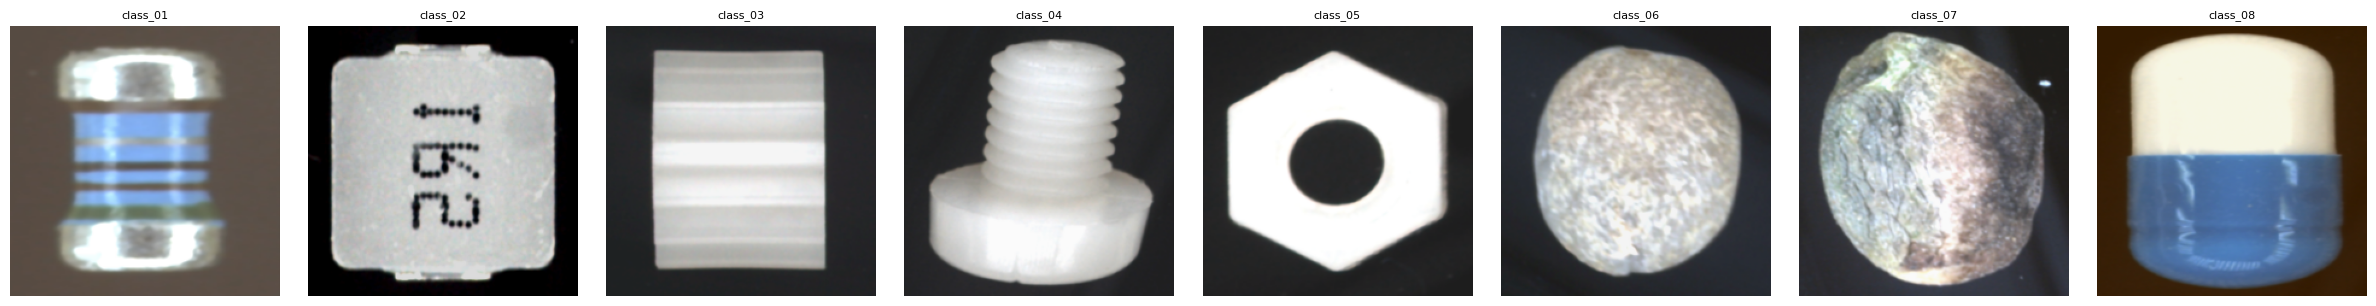

In [ ]:
# Preview one training image per class
classes = sorted({s.class_name for s in train_good})
fig, axes = plt.subplots(1, len(classes), figsize=(3 * len(classes), 3))
if len(classes) == 1:
    axes = [axes]
for ax, cls in zip(axes, classes):
    sample = next(s for s in train_good if s.class_name == cls)
    img = np.array(PILImage.open(sample.image_path).convert("RGB"))
    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

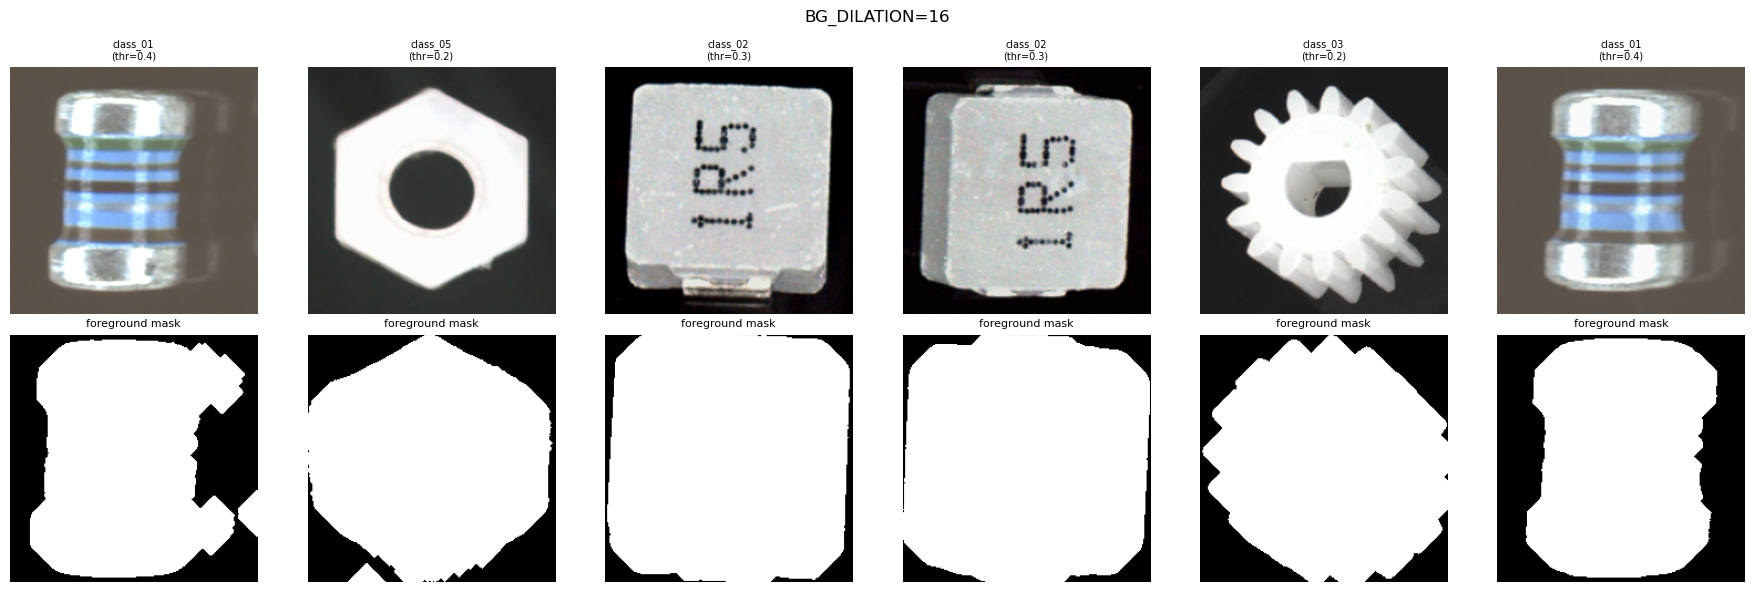

In [ ]:
# Sanity check: visualize foreground masks on a few training images
if NO_BACKGROUND:
    def _preview_foreground_mask(image_np, threshold, dilation):
        # Foreground = pixels brighter than threshold (products are bright, background is black).
        # binary_fill_holes closes any dark holes inside the product region.
        gray = image_np.mean(axis=2)
        fg = binary_fill_holes(gray > threshold)
        if dilation > 0:
            fg = _bdilate(fg, iterations=dilation)
        return fg.astype(np.float32)

    samples_preview = random.sample(train_good, 6)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for col, sample in enumerate(samples_preview):
        img = np.array(PILImage.open(sample.image_path).convert("RGB").resize(
            (config["data"]["image_size"], config["data"]["image_size"]))) / 255.0
        threshold = get_bg_threshold(sample.class_name)
        mask = _preview_foreground_mask(img, threshold, BG_DILATION)
        axes[0, col].imshow(img)
        axes[0, col].set_title(f"{sample.class_name}\n(thr={threshold})", fontsize=7)
        axes[0, col].axis("off")
        axes[1, col].imshow(mask, cmap="gray", vmin=0, vmax=1)
        axes[1, col].set_title("foreground mask", fontsize=8)
        axes[1, col].axis("off")
    plt.suptitle(f"BG_DILATION={BG_DILATION}")
    plt.tight_layout()
    plt.show()

## Training

Backbone: wide_resnet50_2 | grid=28x28 | feat_dim=1536

Fitting MLP for class_01: 2625 images (25 anomalous)


  Patch dataset: 22,000 patches | 2,000 anomalous (9.09%) | ratio=10:1
  Focal loss: alpha=0.909, gamma=2.0
  [class_01] MLP epoch 01/25 | loss=0.01375 | lr=9.96e-04
  [class_01] MLP epoch 02/25 | loss=0.00374 | lr=9.84e-04
  [class_01] MLP epoch 03/25 | loss=0.00222 | lr=9.65e-04
  [class_01] MLP epoch 04/25 | loss=0.00149 | lr=9.38e-04
  [class_01] MLP epoch 05/25 | loss=0.00118 | lr=9.05e-04
  [class_01] MLP epoch 06/25 | loss=0.00095 | lr=8.65e-04
  [class_01] MLP epoch 07/25 | loss=0.00080 | lr=8.19e-04
  [class_01] MLP epoch 08/25 | loss=0.00062 | lr=7.68e-04
  [class_01] MLP epoch 09/25 | loss=0.00053 | lr=7.13e-04
  [class_01] MLP epoch 10/25 | loss=0.00045 | lr=6.55e-04
  [class_01] MLP epoch 11/25 | loss=0.00038 | lr=5.94e-04
  [class_01] MLP epoch 12/25 | loss=0.00033 | lr=5.32e-04
  [class_01] MLP epoch 13/25 | loss=0.00031 | lr=4.69e-04
  [class_01] MLP epoch 14/25 | loss=0.00026 | lr=4.07e-04
  [class_01] MLP epoch 15/25 | loss=0.00024 | lr=3.46e-04
  [class_01] MLP epoch

  Patch dataset: 54,648 patches | 4,968 anomalous (9.09%) | ratio=10:1
  Focal loss: alpha=0.909, gamma=2.0
  [class_02] MLP epoch 01/25 | loss=0.00737 | lr=9.96e-04
  [class_02] MLP epoch 02/25 | loss=0.00133 | lr=9.84e-04
  [class_02] MLP epoch 03/25 | loss=0.00083 | lr=9.65e-04
  [class_02] MLP epoch 04/25 | loss=0.00061 | lr=9.38e-04
  [class_02] MLP epoch 05/25 | loss=0.00049 | lr=9.05e-04
  [class_02] MLP epoch 06/25 | loss=0.00039 | lr=8.65e-04
  [class_02] MLP epoch 07/25 | loss=0.00034 | lr=8.19e-04
  [class_02] MLP epoch 08/25 | loss=0.00027 | lr=7.68e-04
  [class_02] MLP epoch 09/25 | loss=0.00025 | lr=7.13e-04
  [class_02] MLP epoch 10/25 | loss=0.00022 | lr=6.55e-04
  [class_02] MLP epoch 11/25 | loss=0.00020 | lr=5.94e-04
  [class_02] MLP epoch 12/25 | loss=0.00018 | lr=5.32e-04
  [class_02] MLP epoch 13/25 | loss=0.00014 | lr=4.69e-04
  [class_02] MLP epoch 14/25 | loss=0.00011 | lr=4.07e-04
  [class_02] MLP epoch 15/25 | loss=0.00010 | lr=3.46e-04
  [class_02] MLP epoch

  Patch dataset: 11,352 patches | 1,032 anomalous (9.09%) | ratio=10:1
  Focal loss: alpha=0.909, gamma=2.0
  [class_03] MLP epoch 01/25 | loss=0.02027 | lr=9.96e-04
  [class_03] MLP epoch 02/25 | loss=0.00634 | lr=9.84e-04
  [class_03] MLP epoch 03/25 | loss=0.00275 | lr=9.65e-04
  [class_03] MLP epoch 04/25 | loss=0.00177 | lr=9.38e-04
  [class_03] MLP epoch 05/25 | loss=0.00127 | lr=9.05e-04
  [class_03] MLP epoch 06/25 | loss=0.00102 | lr=8.65e-04
  [class_03] MLP epoch 07/25 | loss=0.00075 | lr=8.19e-04
  [class_03] MLP epoch 08/25 | loss=0.00065 | lr=7.68e-04
  [class_03] MLP epoch 09/25 | loss=0.00055 | lr=7.13e-04
  [class_03] MLP epoch 10/25 | loss=0.00050 | lr=6.55e-04
  [class_03] MLP epoch 11/25 | loss=0.00037 | lr=5.94e-04
  [class_03] MLP epoch 12/25 | loss=0.00036 | lr=5.32e-04
  [class_03] MLP epoch 13/25 | loss=0.00032 | lr=4.69e-04
  [class_03] MLP epoch 14/25 | loss=0.00027 | lr=4.07e-04
  [class_03] MLP epoch 15/25 | loss=0.00025 | lr=3.46e-04
  [class_03] MLP epoch

  Patch dataset: 27,808 patches | 2,528 anomalous (9.09%) | ratio=10:1
  Focal loss: alpha=0.909, gamma=2.0
  [class_04] MLP epoch 01/25 | loss=0.01348 | lr=9.96e-04
  [class_04] MLP epoch 02/25 | loss=0.00301 | lr=9.84e-04
  [class_04] MLP epoch 03/25 | loss=0.00172 | lr=9.65e-04
  [class_04] MLP epoch 04/25 | loss=0.00115 | lr=9.38e-04
  [class_04] MLP epoch 05/25 | loss=0.00087 | lr=9.05e-04
  [class_04] MLP epoch 06/25 | loss=0.00066 | lr=8.65e-04
  [class_04] MLP epoch 07/25 | loss=0.00054 | lr=8.19e-04
  [class_04] MLP epoch 08/25 | loss=0.00043 | lr=7.68e-04
  [class_04] MLP epoch 09/25 | loss=0.00038 | lr=7.13e-04
  [class_04] MLP epoch 10/25 | loss=0.00033 | lr=6.55e-04
  [class_04] MLP epoch 11/25 | loss=0.00030 | lr=5.94e-04
  [class_04] MLP epoch 12/25 | loss=0.00024 | lr=5.32e-04
  [class_04] MLP epoch 13/25 | loss=0.00022 | lr=4.69e-04
  [class_04] MLP epoch 14/25 | loss=0.00019 | lr=4.07e-04
  [class_04] MLP epoch 15/25 | loss=0.00017 | lr=3.46e-04
  [class_04] MLP epoch

...

  TTA [class_04] done: 745 images x 4 augments
TTA inference [class_05] (225 images)...


  TTA [class_05] done: 225 images x 8 augments
TTA inference [class_06] (1010 images)...


  TTA [class_06] done: 1010 images x 8 augments
TTA inference [class_07] (915 images)...


  TTA [class_07] done: 915 images x 8 augments
TTA inference [class_08] (960 images)...


  TTA [class_08] done: 960 images x 4 augments


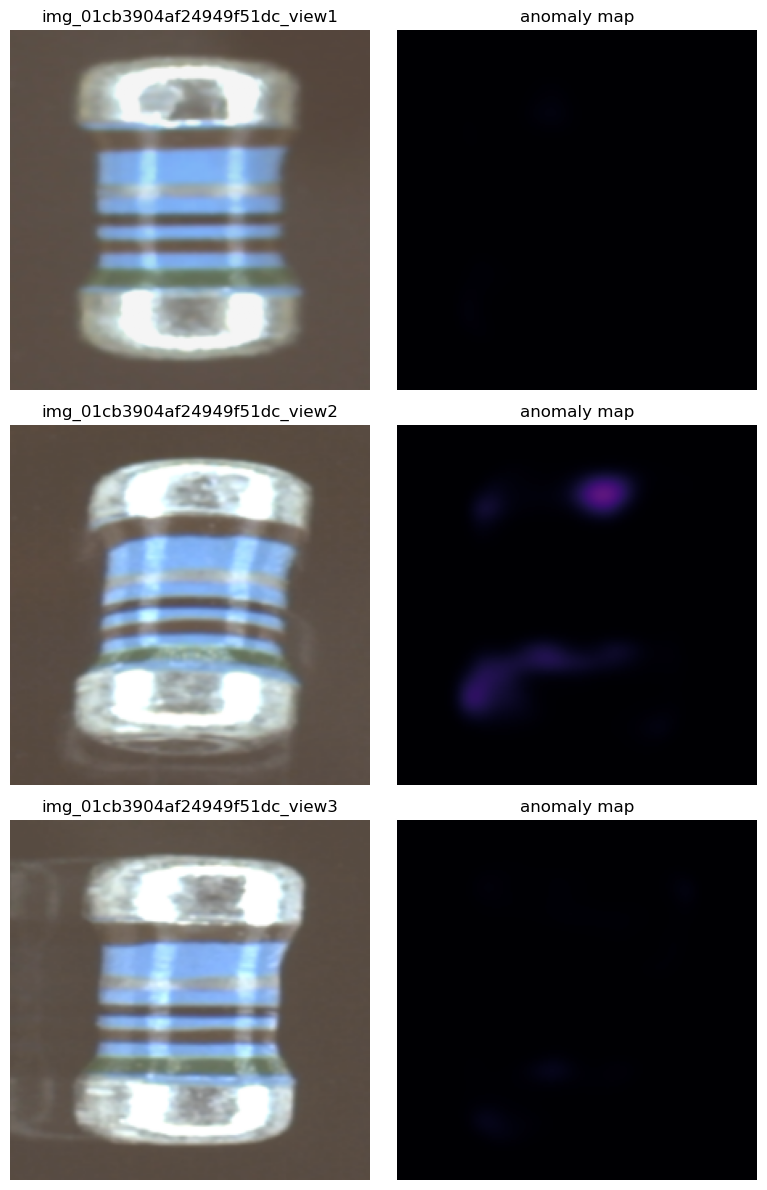

In [ ]:
# --- Train WideResNet50 MLP ---
if TRAIN_MLP and train_good_fit and test:
    Method = get_method_class(MLP_CONFIG["method"]["name"])
    runner = ExperimentRunner(Method(MLP_CONFIG), MLP_CONFIG)
    runner.fit(train_good_fit + train_anomalies_fit)
    mlp_predictions = runner.method.predict(test, tta=TTA)
    show_predictions(test, mlp_predictions, n=3)
else:
    runner = None
    mlp_predictions = {}
    print("WideResNet50 skipped (TRAIN_MLP=False)")

In [ ]:
# --- Train DINOv2 MLP ---
if TRAIN_DINO and train_good_fit and test:
    d2_Method = get_method_class(DINO_CONFIG["method"]["name"])
    d2_runner = ExperimentRunner(d2_Method(DINO_CONFIG), DINO_CONFIG)
    d2_runner.fit(train_good_fit + train_anomalies_fit)
    dinov2_predictions = d2_runner.method.predict(test, tta=TTA)
    print(f"DINOv2 predictions: {len(dinov2_predictions)} images")
else:
    d2_runner = None
    dinov2_predictions = {}
    print("DINOv2 skipped (TRAIN_DINO=False)")

Using cache found in C:\Users\PC/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\PC/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\PC/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\PC/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
C:\Users\PC/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:74: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  x = nn.functional.scaled_dot_product_attention(


Backbone: dinov2_vitb14 | grid=16x16 | feat_dim=3072 (n_layers=4)

Fitting MLP for class_01: 2625 images (25 anomalous)


  Patch dataset: 16,968 patches | 168 anomalous (0.99%) | ratio=100:1
  Focal loss: alpha=0.950, gamma=2.0
  [class_01] MLP epoch 01/20 | loss=0.00665 | lr=1.00e-03
  [class_01] MLP epoch 02/20 | loss=0.00114 | lr=1.00e-03
  [class_01] MLP epoch 03/20 | loss=0.00041 | lr=1.00e-03
  [class_01] MLP epoch 04/20 | loss=0.00033 | lr=1.00e-03
  [class_01] MLP epoch 05/20 | loss=0.00016 | lr=1.00e-03
  [class_01] MLP epoch 06/20 | loss=0.00010 | lr=1.00e-03
  [class_01] MLP epoch 07/20 | loss=0.00009 | lr=1.00e-03
  [class_01] MLP epoch 08/20 | loss=0.00006 | lr=1.00e-03
  [class_01] MLP epoch 09/20 | loss=0.00006 | lr=1.00e-03
  [class_01] MLP epoch 10/20 | loss=0.00005 | lr=1.00e-03
  [class_01] MLP epoch 11/20 | loss=0.00009 | lr=1.00e-03
  [class_01] MLP epoch 12/20 | loss=0.00003 | lr=1.00e-03
  [class_01] MLP epoch 13/20 | loss=0.00002 | lr=1.00e-03
  [class_01] MLP epoch 14/20 | loss=0.00002 | lr=1.00e-03
  [class_01] MLP epoch 15/20 | loss=0.00001 | lr=1.00e-03
  [class_01] MLP epoch 

  Patch dataset: 41,511 patches | 411 anomalous (0.99%) | ratio=100:1
  Focal loss: alpha=0.950, gamma=2.0
  [class_02] MLP epoch 01/20 | loss=0.00370 | lr=1.00e-03
  [class_02] MLP epoch 02/20 | loss=0.00045 | lr=1.00e-03
  [class_02] MLP epoch 03/20 | loss=0.00021 | lr=1.00e-03
  [class_02] MLP epoch 04/20 | loss=0.00010 | lr=1.00e-03
  [class_02] MLP epoch 05/20 | loss=0.00008 | lr=1.00e-03
  [class_02] MLP epoch 06/20 | loss=0.00005 | lr=1.00e-03
  [class_02] MLP epoch 07/20 | loss=0.00003 | lr=1.00e-03
  [class_02] MLP epoch 08/20 | loss=0.00002 | lr=1.00e-03
  [class_02] MLP epoch 09/20 | loss=0.00001 | lr=1.00e-03
  [class_02] MLP epoch 10/20 | loss=0.00001 | lr=1.00e-03
  [class_02] MLP epoch 11/20 | loss=0.00001 | lr=1.00e-03
  [class_02] MLP epoch 12/20 | loss=0.00001 | lr=1.00e-03
  [class_02] MLP epoch 13/20 | loss=0.00000 | lr=1.00e-03
  [class_02] MLP epoch 14/20 | loss=0.00001 | lr=1.00e-03
  [class_02] MLP epoch 15/20 | loss=0.00000 | lr=1.00e-03
  [class_02] MLP epoch 

  Patch dataset: 4,242 patches | 42 anomalous (0.99%) | ratio=100:1
  Focal loss: alpha=0.950, gamma=2.0
  [class_03] MLP epoch 01/20 | loss=0.00579 | lr=1.00e-03
  [class_03] MLP epoch 02/20 | loss=0.03255 | lr=1.00e-03
  [class_03] MLP epoch 03/20 | loss=0.00197 | lr=1.00e-03
  [class_03] MLP epoch 04/20 | loss=0.00118 | lr=1.00e-03
  [class_03] MLP epoch 05/20 | loss=0.00111 | lr=1.00e-03
  [class_03] MLP epoch 06/20 | loss=0.00059 | lr=1.00e-03
  [class_03] MLP epoch 07/20 | loss=0.00028 | lr=1.00e-03
  [class_03] MLP epoch 08/20 | loss=0.00015 | lr=1.00e-03
  [class_03] MLP epoch 09/20 | loss=0.00026 | lr=1.00e-03
  [class_03] MLP epoch 10/20 | loss=0.00006 | lr=1.00e-03
  [class_03] MLP epoch 11/20 | loss=0.00005 | lr=1.00e-03
  [class_03] MLP epoch 12/20 | loss=0.00003 | lr=1.00e-03
  [class_03] MLP epoch 13/20 | loss=0.00002 | lr=1.00e-03
  [class_03] MLP epoch 14/20 | loss=0.00002 | lr=1.00e-03
  [class_03] MLP epoch 15/20 | loss=0.00002 | lr=1.00e-03
  [class_03] MLP epoch 16

...

  TTA [class_04] done: 745 images x 4 augments
TTA inference [class_05] (225 images)...


  TTA [class_05] done: 225 images x 8 augments
TTA inference [class_06] (1010 images)...


  TTA [class_06] done: 1010 images x 8 augments
TTA inference [class_07] (915 images)...


  TTA [class_07] done: 915 images x 8 augments
TTA inference [class_08] (960 images)...


  TTA [class_08] done: 960 images x 4 augments
DINOv2 predictions: 5910 images


In [ ]:
# --- Train ConvNeXT-Large MLP ---
if TRAIN_CONVNEXT and train_good_fit and test:
    cx_Method = get_method_class(CONVNEXT_CONFIG["method"]["name"])
    cx_runner = ExperimentRunner(cx_Method(CONVNEXT_CONFIG), CONVNEXT_CONFIG)
    cx_runner.fit(train_good_fit + train_anomalies_fit)
    convnext_predictions = cx_runner.method.predict(test, tta=TTA)
    print(f"ConvNeXT-Large predictions: {len(convnext_predictions)} images")
else:
    cx_runner = None
    convnext_predictions = {}
    print("ConvNeXT-Large skipped (TRAIN_CONVNEXT=False)")

Backbone: convnext_large | grid=28x28 | feat_dim=1152

Fitting MLP for class_01: 2625 images (25 anomalous)


  Patch dataset: 22,000 patches | 2,000 anomalous (9.09%) | ratio=10:1
  Focal loss: alpha=0.909, gamma=2.0
  [class_01] MLP epoch 01/25 | loss=0.01124 | lr=9.96e-04
  [class_01] MLP epoch 02/25 | loss=0.00274 | lr=9.84e-04
  [class_01] MLP epoch 03/25 | loss=0.00152 | lr=9.65e-04
  [class_01] MLP epoch 04/25 | loss=0.00104 | lr=9.38e-04
  [class_01] MLP epoch 05/25 | loss=0.00082 | lr=9.05e-04
  [class_01] MLP epoch 06/25 | loss=0.00069 | lr=8.65e-04
  [class_01] MLP epoch 07/25 | loss=0.00056 | lr=8.19e-04
  [class_01] MLP epoch 08/25 | loss=0.00045 | lr=7.68e-04
  [class_01] MLP epoch 09/25 | loss=0.00039 | lr=7.13e-04
  [class_01] MLP epoch 10/25 | loss=0.00030 | lr=6.55e-04
  [class_01] MLP epoch 11/25 | loss=0.00025 | lr=5.94e-04
  [class_01] MLP epoch 12/25 | loss=0.00022 | lr=5.32e-04
  [class_01] MLP epoch 13/25 | loss=0.00021 | lr=4.69e-04
  [class_01] MLP epoch 14/25 | loss=0.00019 | lr=4.07e-04
  [class_01] MLP epoch 15/25 | loss=0.00017 | lr=3.46e-04
  [class_01] MLP epoch

  Patch dataset: 54,648 patches | 4,968 anomalous (9.09%) | ratio=10:1
  Focal loss: alpha=0.909, gamma=2.0
  [class_02] MLP epoch 01/25 | loss=0.00668 | lr=9.96e-04
  [class_02] MLP epoch 02/25 | loss=0.00120 | lr=9.84e-04
  [class_02] MLP epoch 03/25 | loss=0.00078 | lr=9.65e-04
  [class_02] MLP epoch 04/25 | loss=0.00062 | lr=9.38e-04
  [class_02] MLP epoch 05/25 | loss=0.00052 | lr=9.05e-04
  [class_02] MLP epoch 06/25 | loss=0.00044 | lr=8.65e-04
  [class_02] MLP epoch 07/25 | loss=0.00032 | lr=8.19e-04
  [class_02] MLP epoch 08/25 | loss=0.00027 | lr=7.68e-04
  [class_02] MLP epoch 09/25 | loss=0.00020 | lr=7.13e-04
  [class_02] MLP epoch 10/25 | loss=0.00016 | lr=6.55e-04
  [class_02] MLP epoch 11/25 | loss=0.00013 | lr=5.94e-04
  [class_02] MLP epoch 12/25 | loss=0.00014 | lr=5.32e-04
  [class_02] MLP epoch 13/25 | loss=0.00013 | lr=4.69e-04
  [class_02] MLP epoch 14/25 | loss=0.00011 | lr=4.07e-04
  [class_02] MLP epoch 15/25 | loss=0.00009 | lr=3.46e-04
  [class_02] MLP epoch

  Patch dataset: 11,352 patches | 1,032 anomalous (9.09%) | ratio=10:1
  Focal loss: alpha=0.909, gamma=2.0
  [class_03] MLP epoch 01/25 | loss=0.01954 | lr=9.96e-04
  [class_03] MLP epoch 02/25 | loss=0.00615 | lr=9.84e-04
  [class_03] MLP epoch 03/25 | loss=0.00291 | lr=9.65e-04
  [class_03] MLP epoch 04/25 | loss=0.00194 | lr=9.38e-04
  [class_03] MLP epoch 05/25 | loss=0.00144 | lr=9.05e-04
  [class_03] MLP epoch 06/25 | loss=0.00117 | lr=8.65e-04
  [class_03] MLP epoch 07/25 | loss=0.00091 | lr=8.19e-04
  [class_03] MLP epoch 08/25 | loss=0.00079 | lr=7.68e-04
  [class_03] MLP epoch 09/25 | loss=0.00066 | lr=7.13e-04
  [class_03] MLP epoch 10/25 | loss=0.00059 | lr=6.55e-04
  [class_03] MLP epoch 11/25 | loss=0.00050 | lr=5.94e-04
  [class_03] MLP epoch 12/25 | loss=0.00047 | lr=5.32e-04
  [class_03] MLP epoch 13/25 | loss=0.00042 | lr=4.69e-04
  [class_03] MLP epoch 14/25 | loss=0.00039 | lr=4.07e-04
  [class_03] MLP epoch 15/25 | loss=0.00035 | lr=3.46e-04
  [class_03] MLP epoch

  Patch dataset: 27,808 patches | 2,528 anomalous (9.09%) | ratio=10:1
  Focal loss: alpha=0.909, gamma=2.0
  [class_04] MLP epoch 01/25 | loss=0.01147 | lr=9.96e-04
  [class_04] MLP epoch 02/25 | loss=0.00228 | lr=9.84e-04
  [class_04] MLP epoch 03/25 | loss=0.00131 | lr=9.65e-04
  [class_04] MLP epoch 04/25 | loss=0.00095 | lr=9.38e-04
  [class_04] MLP epoch 05/25 | loss=0.00069 | lr=9.05e-04
  [class_04] MLP epoch 06/25 | loss=0.00051 | lr=8.65e-04
  [class_04] MLP epoch 07/25 | loss=0.00042 | lr=8.19e-04
  [class_04] MLP epoch 08/25 | loss=0.00034 | lr=7.68e-04
  [class_04] MLP epoch 09/25 | loss=0.00028 | lr=7.13e-04
  [class_04] MLP epoch 10/25 | loss=0.00024 | lr=6.55e-04
  [class_04] MLP epoch 11/25 | loss=0.00021 | lr=5.94e-04
  [class_04] MLP epoch 12/25 | loss=0.00020 | lr=5.32e-04
  [class_04] MLP epoch 13/25 | loss=0.00019 | lr=4.69e-04
  [class_04] MLP epoch 14/25 | loss=0.00015 | lr=4.07e-04
  [class_04] MLP epoch 15/25 | loss=0.00014 | lr=3.46e-04
  [class_04] MLP epoch

...

  TTA [class_04] done: 745 images x 4 augments
TTA inference [class_05] (225 images)...


  TTA [class_05] done: 225 images x 8 augments
TTA inference [class_06] (1010 images)...


  TTA [class_06] done: 1010 images x 8 augments
TTA inference [class_07] (915 images)...


  TTA [class_07] done: 915 images x 8 augments
TTA inference [class_08] (960 images)...


  TTA [class_08] done: 960 images x 4 augments
ConvNeXT-Large predictions: 5910 images


In [ ]:
# --- Ensemble: 3-way per-pixel max (WR50 + DINOv2 + ConvNeXT) ---
# Per-pixel max preserves each model's full confidence: a defect caught by
# any one model contributes its full score without being diluted by the others.
print(f"Toggles: TTA={TTA} | ENSEMBLE={ENSEMBLE} | TRAIN_CONVNEXT={TRAIN_CONVNEXT}")
import numpy as np

# Step 1: base ensemble (WR50 + DINOv2)
if ENSEMBLE and mlp_predictions and dinov2_predictions:
    print("Per-pixel max: WR50 + DINOv2...")
    predictions = {
        iid: np.maximum(
            mlp_predictions[iid].astype(np.float32),
            dinov2_predictions[iid].astype(np.float32)
        ).astype(np.float16)
        for iid in mlp_predictions
    }
    print(f"WR50+DINOv2 ensemble: {len(predictions)} predictions")
elif mlp_predictions:
    predictions = mlp_predictions
    print(f"WR50 standalone: {len(predictions)} images")
elif dinov2_predictions:
    predictions = dinov2_predictions
    print(f"DINOv2 standalone: {len(predictions)} images")
else:
    predictions = {}

# Step 2: add ConvNeXT on top if available
if convnext_predictions:
    if predictions:
        print("+ ConvNeXT-Large: 3-way max...")
        predictions = {
            iid: np.maximum(
                predictions[iid].astype(np.float32),
                convnext_predictions[iid].astype(np.float32)
            ).astype(np.float16)
            for iid in predictions
        }
        print(f"WR50+DINOv2+ConvNeXT ensemble: {len(predictions)} predictions")
    else:
        predictions = convnext_predictions
        print(f"ConvNeXT standalone: {len(predictions)} predictions")


Toggles: TTA=True | ENSEMBLE=True | TRAIN_CONVNEXT=True
Per-pixel max: WR50 + DINOv2...
WR50+DINOv2 ensemble: 5910 predictions
+ ConvNeXT-Large: 3-way max...
WR50+DINOv2+ConvNeXT ensemble: 5910 predictions


In [ ]:
# Background suppression: zero out outer black background in each prediction map
if NO_BACKGROUND and predictions:
    image_size = config["data"]["image_size"]
    id_to_sample = {s.image_id: s for s in test}

    for img_id, pred in predictions.items():
        sample = id_to_sample[img_id]
        threshold = get_bg_threshold(sample.class_name)
        img = np.array(PILImage.open(sample.image_path).convert("RGB").resize(
            (image_size, image_size))) / 255.0
        fg = binary_fill_holes(img.mean(axis=2) > threshold)
        if BG_DILATION > 0:
            fg = _bdilate(fg, iterations=BG_DILATION)
        predictions[img_id] = (pred.astype(np.float32) * fg).astype(np.float16)

    print("Background suppression applied.")

Background suppression applied.


In [ ]:
# Multi-view fusion + consistency
sample_to_views = defaultdict(list)
for s in test:
    sample_to_views[s.sample_id].append(s.image_id)

# --- Multi-view fusion: propagate max score across all 5 views ---
# If any view of a sample scores high, scale all other views up to match.
# Rationale: a real defect should be detectable from multiple angles.
if MULTI_VIEW_FUSION and predictions:
    n_boosted = 0
    for image_ids in sample_to_views.values():
        maps = [predictions[iid] for iid in image_ids if iid in predictions]
        if not maps: continue
        sample_max = max(float(m.max()) for m in maps)
        for iid in image_ids:
            if iid not in predictions: continue
            view_max = float(predictions[iid].max())
            if view_max < sample_max - 1e-6:
                scale = sample_max / max(view_max, 1e-6)
                predictions[iid] = np.clip(
                    predictions[iid] * scale, 0.0, 1.0
                ).astype(predictions[iid].dtype)
                n_boosted += 1
    print(f"Multi-view fusion: {n_boosted} views boosted out of {len(predictions)} total")

# --- Multi-view consistency: boost samples where views strongly disagree ---
# If one view scores much higher than average, the whole sample gets a boost.
# boost > 1 when s_max >> s_mean (high disagreement), boost → 1 when all views agree.
if MULTI_VIEW_CONSISTENCY and predictions:
    n_boosted = 0
    for image_ids in sample_to_views.values():
        present = [iid for iid in image_ids if iid in predictions]
        if len(present) < 2: continue
        scores = [float(predictions[iid].max()) for iid in present]
        s_max, s_mean = max(scores), float(np.mean(scores))
        if s_mean < 1e-6: continue
        boost = 1.0 + CONSISTENCY_ALPHA * (s_max - s_mean) / (s_max + 1e-6)
        for iid in present:
            predictions[iid] = np.clip(
                predictions[iid] * boost, 0.0, 1.0
            ).astype(predictions[iid].dtype)
            n_boosted += 1
    print(f"Multi-view consistency: boost applied to {n_boosted} views (alpha={CONSISTENCY_ALPHA})")

Multi-view fusion: 4468 views boosted out of 5910 total
Multi-view consistency: boost applied to 5910 views (alpha=0.5)


## Extracting images

In [ ]:
# ── Score over training anomalies (they have GT masks) ───────────────────────
# Re-run predictions on train_anomalies for the three models
train_anom_wr50  = runner.method.predict(train_anomalies, tta=TTA)
train_anom_dino  = d2_runner.method.predict(train_anomalies, tta=TTA)
train_anom_cx    = cx_runner.method.predict(train_anomalies, tta=TTA)
train_anom_ens   = {
    iid: np.maximum(np.maximum(
        train_anom_wr50[iid].astype(np.float32),
        train_anom_dino[iid].astype(np.float32)),
        train_anom_cx[iid].astype(np.float32)).astype(np.float16)
    for iid in train_anom_wr50
}

id_to_train_anom = {s.image_id: s for s in train_anomalies}

common_ids = set(train_anom_wr50) & set(train_anom_dino) & set(train_anom_cx)

In [ ]:
scores = {}
for iid in common_ids:
    sample = id_to_train_anom[iid]
    if sample.class_name != "class_02":
        continue

    m1  = train_anom_wr50[iid].astype(np.float32)
    m2  = train_anom_dino[iid].astype(np.float32)
    m3  = train_anom_cx[iid].astype(np.float32)
    ens = train_anom_ens[iid].astype(np.float32)

    if ens.max() < 0.3:
        continue

    disagreement = np.stack([m1, m2, m3], axis=0).std(axis=0).mean()
    scores[iid] = disagreement

top15 = sorted(scores, key=scores.get, reverse=True)[:15]
print("Top candidates (most model disagreement):")
for iid in top15:
    print(f"  {iid}  disagreement={scores[iid]:.4f}")

# ── Visualize single candidate (2×3 grid) ────────────────────────────────────
chosen_id = top15[4]  # swap index (0-14) to try others

sample = id_to_train_anom[chosen_id]
img = np.array(PILImage.open(sample.image_path).convert("RGB").resize((224, 224)))
gt  = load_sample_mask(sample, (224, 224)).astype(np.float32)

m1  = train_anom_wr50[chosen_id].astype(np.float32)
m2  = train_anom_dino[chosen_id].astype(np.float32)
m3  = train_anom_cx[chosen_id].astype(np.float32)
ens = train_anom_ens[chosen_id].astype(np.float32)

titles = ["Original", "Ground Truth", "WideResNet50",
          "DINOv2",   "ConvNeXT-L",   "Ensemble (max)"]
maps   = [img, gt, m1, m2, m3, ens]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, title, data in zip(axes.flat, titles, maps):
    if title == "Original":
        ax.imshow(data)
    else:
        im = ax.imshow(data, cmap="hot", vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=13)
    ax.axis("off")

fig.suptitle(f"{chosen_id}  (disagreement={scores[chosen_id]:.3f})", fontsize=11)
plt.tight_layout()
plt.savefig("ensemble_comparison_single.png", dpi=150, bbox_inches="tight")
plt.show()


NameError: name 'common_ids' is not defined

## Validation + File saving

In [ ]:
# Validation: mirrors the full submission pipeline (bg suppression + multi-view)
# Only runs when VALIDATE=True
if VALIDATE and predictions:
    val_samples = train_anomalies_val + random.sample(
        train_good_val, min(200, len(train_good_val)))

    # Step 1: base val ensemble
    if ENSEMBLE and mlp_predictions and runner is not None and dinov2_predictions and d2_runner is not None:
        wr_val = runner.method.predict(val_samples, tta=TTA)
        d2_val = d2_runner.method.predict(val_samples, tta=TTA)
        val_predictions = {
            iid: np.maximum(
                wr_val[iid].astype(np.float32),
                d2_val[iid].astype(np.float32)
            ).astype(np.float16)
            for iid in wr_val
        }
        print(f"WR50+DINOv2 val ensemble: {len(val_predictions)} predictions")
    elif mlp_predictions and runner is not None:
        val_predictions = runner.method.predict(val_samples, tta=TTA)
        print(f"WR50 val: {len(val_predictions)} predictions")
    elif dinov2_predictions and d2_runner is not None:
        val_predictions = d2_runner.method.predict(val_samples, tta=TTA)
        print(f"DINOv2 val: {len(val_predictions)} predictions")
    else:
        val_predictions = {}

    # Step 2: add ConvNeXT to val ensemble if trained
    if convnext_predictions and cx_runner is not None:
        cx_val = cx_runner.method.predict(val_samples, tta=TTA)
        if val_predictions:
            val_predictions = {
                iid: np.maximum(
                    val_predictions[iid].astype(np.float32),
                    cx_val[iid].astype(np.float32)
                ).astype(np.float16)
                for iid in val_predictions
            }
            print(f"+ ConvNeXT val: 3-way max, {len(val_predictions)} predictions")
        else:
            val_predictions = cx_val
            print(f"ConvNeXT val standalone: {len(val_predictions)} predictions")

    print(f"val_samples: {len(val_samples)} / val_predictions: {len(val_predictions)}")

    # Step 3: background suppression
    if NO_BACKGROUND and val_predictions:
        id_to_sample = {s.image_id: s for s in val_samples}
        image_size   = config["data"]["image_size"]
        for img_id, pred in val_predictions.items():
            s   = id_to_sample[img_id]
            thr = get_bg_threshold(s.class_name)
            img = np.array(PILImage.open(s.image_path).convert("RGB").resize(
                (image_size, image_size))) / 255.0
            fg  = binary_fill_holes(img.mean(axis=2) > thr)
            if BG_DILATION > 0: fg = _bdilate(fg, iterations=BG_DILATION)
            val_predictions[img_id] = (pred.astype(np.float32) * fg).astype(np.float16)

    # Step 4: multi-view fusion + consistency
    val_sample_to_views = defaultdict(list)
    for s in val_samples:
        val_sample_to_views[s.sample_id].append(s.image_id)

    if MULTI_VIEW_FUSION and val_predictions:
        for image_ids in val_sample_to_views.values():
            maps = [val_predictions[iid] for iid in image_ids if iid in val_predictions]
            if not maps: continue
            sample_max = max(float(m.max()) for m in maps)
            for iid in image_ids:
                if iid not in val_predictions: continue
                view_max = float(val_predictions[iid].max())
                if view_max < sample_max - 1e-6:
                    val_predictions[iid] = np.clip(
                        val_predictions[iid] * (sample_max / max(view_max, 1e-6)), 0.0, 1.0
                    ).astype(val_predictions[iid].dtype)

    if MULTI_VIEW_CONSISTENCY and val_predictions:
        for image_ids in val_sample_to_views.values():
            present = [iid for iid in image_ids if iid in val_predictions]
            if len(present) < 2: continue
            scores = [float(val_predictions[iid].max()) for iid in present]
            s_max, s_mean = max(scores), float(np.mean(scores))
            if s_mean < 1e-6: continue
            boost = 1.0 + CONSISTENCY_ALPHA * (s_max - s_mean) / (s_max + 1e-6)
            for iid in present:
                val_predictions[iid] = np.clip(
                    val_predictions[iid] * boost, 0.0, 1.0
                ).astype(val_predictions[iid].dtype)

    # Evaluate
    if train_anomalies_val and val_predictions:
        metrics = evaluate_predictions(val_samples, val_predictions).as_dict()
        n_models = sum([bool(mlp_predictions), bool(dinov2_predictions), bool(convnext_predictions)])
        mode = f"{n_models}-way max ensemble" if n_models > 1 else (
            "ConvNeXT" if convnext_predictions else ("WR50 (TTA)" if TTA else "WR50"))
        print(f"[{mode}] {len(train_anomalies_val)} anomalies + {min(200, len(train_good_val))} normals")
        print(f"Pixel AP:    {metrics['pixel_ap']:.4f}")
        print(f"Image AP:    {metrics['image_ap']:.4f}")
        auroc = metrics['pixel_auroc']
        print(f"Pixel AUROC: {auroc:.4f}" if auroc is not None else "Pixel AUROC: N/A")
    else:
        print("No held-out anomalies — set VALIDATE=True for local eval")

    image_size = config["data"]["image_size"]
    grouped = {}
    for s in train_anomalies_val:
        grouped.setdefault(s.class_name, []).append(s)

    if grouped and val_predictions:
        N_ANOM = 4
        n_cls  = len(grouped)
        fig, axes = plt.subplots(n_cls, N_ANOM * 3, figsize=(N_ANOM * 9, 3 * n_cls), squeeze=False)
        for row, (cls, slist) in enumerate(sorted(grouped.items())):
            picks = random.sample(slist, min(N_ANOM, len(slist)))
            for col_off, s in enumerate(picks):
                img  = np.array(PILImage.open(s.image_path).convert("RGB").resize(
                    (image_size, image_size))) / 255.0
                gt   = load_sample_mask(s, (image_size, image_size)).astype(np.float32)
                pred = np.asarray(val_predictions[s.image_id], dtype=np.float32)
                c = col_off * 3
                axes[row, c].imshow(img);                                  axes[row, c].axis("off")
                axes[row, c].set_title(cls if col_off == 0 else "",        fontsize=7)
                axes[row, c+1].imshow(gt,   cmap="hot", vmin=0, vmax=1);  axes[row, c+1].axis("off")
                axes[row, c+1].set_title("GT" if row == 0 else "",         fontsize=7)
                axes[row, c+2].imshow(pred, cmap="hot", vmin=0, vmax=1);  axes[row, c+2].axis("off")
                axes[row, c+2].set_title("pred" if row == 0 else "",       fontsize=7)
        plt.suptitle("Anomalies vs prediction", fontsize=9)
        plt.tight_layout(); plt.show()

    if val_predictions:
        N_NORM     = 12
        norm_picks = random.sample(
            [s for s in train_good_val if s.image_id in val_predictions],
            min(N_NORM, len(train_good_val)))
        fig, axes  = plt.subplots(2, N_NORM, figsize=(2 * N_NORM, 6))
        for col, s in enumerate(norm_picks):
            img  = np.array(PILImage.open(s.image_path).convert("RGB").resize(
                (image_size, image_size))) / 255.0
            pred = np.asarray(val_predictions[s.image_id], dtype=np.float32)
            axes[0, col].imshow(img); axes[0, col].axis("off")
            axes[0, col].set_title(s.class_name, fontsize=6)
            axes[1, col].imshow(pred, cmap="hot", vmin=0, vmax=1); axes[1, col].axis("off")
            axes[1, col].set_title(f"max={pred.max():.3f}", fontsize=6)
        plt.suptitle("Normal images — should score near zero", fontsize=9)
        plt.tight_layout(); plt.show()

else:
    print("Validation skipped (VALIDATE=False)")


Output hidden; open in https://colab.research.google.com to view.

## File saving

In [ ]:
# Save submission file (set SAVE_FILE=True when submitting)
if predictions and SAVE_FILE:
    expected_shape = (config["data"]["image_size"], config["data"]["image_size"])
    sorted_ids = sorted(predictions)
    assert len(sorted_ids) == len(test), \
        f"Expected {len(test)} predictions, got {len(sorted_ids)}"

    # Spot-check 5 random predictions: decode the q8rle string and verify
    # shape is correct. It catches encoding bugs before upload.
    sample_indices = set(random.sample(range(len(sorted_ids)), min(5, len(sorted_ids))))
    sampled_labels = {}

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    base_path = resolve_path(MLP_CONFIG["submission"]["output_path"], ROOT)
    parts = []
    if TTA:             parts.append("tta")
    if ENSEMBLE: parts.append("wr50_d2_cx")
    stem = "_".join(parts) + f"_{timestamp}" if parts else f"{base_path.stem}_{timestamp}"
    zip_path = base_path.parent / f"{stem}.zip"
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    # Write CSV directly into the zip; avoids creating a large uncompressed file on disk.
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        with zf.open(f"{stem}.csv", "w") as f:
            f.write(b"ID,Label\n")
            for i, img_id in enumerate(sorted_ids):
                label = float_matrix_to_q8rle(_prepare_prediction_map(predictions[img_id]))
                f.write(f"{img_id},{label}\n".encode("utf-8"))
                if i in sample_indices:
                    sampled_labels[img_id] = label

    for img_id, label in sampled_labels.items():
        assert label.startswith("q8rle"), f"Bad label for {img_id}"
        assert q8rle_to_float_matrix(label).shape == expected_shape, \
            f"Shape mismatch for {img_id}"

    print(f"Saved: {zip_path} ({zip_path.stat().st_size / 1024**2:.1f} MB)")
else:
    print("SAVE_FILE=False — set to True to write submission zip.")

Saved: /content/drive/MyDrive/ADL/Project/predictions/tta_wr50_d2_cx_20260520_163540.zip (54.2 MB)
